In [2]:
%matplotlib inline
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib
import scipy.interpolate as interpolate
import scipy.signal as signal
from matplotlib.patches import Rectangle
import scipy.stats as stats
import scipy.constants as const
import scipy.optimize as optimize
import scipy.interpolate as interpolate
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm  # For register_cmap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, FixedLocator
import os

MacBook = False


In [3]:
# Custom colours:
custom_green = (13/256, 179/256, 45/256, 1.0)
custom_blue = (34/255, 125/255, 251/255, 1)  # RGB for blue #227DFB
custom_red = (209/255, 37/255, 55/255, 1)  # RGB for red #D1254E
white = np.array([1, 1, 1, 1])

darken_factor = 0.95  # Or any factor < 1 to darken
dark_green = tuple(np.array(custom_green[:3]) * darken_factor) + (1.0,)
dark_blue  = tuple(np.array(custom_blue[:3])  * darken_factor) + (1.0,)
dark_red   = tuple(np.array(custom_red[:3])   * darken_factor) + (1.0,)

# Custom colour map black white blue
original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsB = original_cmap(np.linspace(0, 1, n_colors))
colorsB[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap_blue = ListedColormap(colorsB)

# Custom colour map black white red
original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsR = original_cmap(np.linspace(0, 1, n_colors))
colorsR[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_red, 128)  # Fade from gray to blue
custom_cmap_red = ListedColormap(colorsR)

# Custom colour map white red
n_colors = 256
colorsWR = np.linspace([1, 1, 1, 1], dark_red, n_colors)
custom_cmap_WR = ListedColormap(colorsWR)

# Custom colour map blue white red
def create_blue_white_red_cmap(white_width=0):
    n_colors = 256
    if white_width % 2 != 0:
        white_width += 1  # Ensure even

    side_len = (n_colors - white_width) // 2

    dark_blue = (0.2, 0.49, 0.9, 1.0)
    dark_red  = (0.82, 0.15, 0.23, 1.0)
    white     = (1.0, 1.0, 1.0, 1.0)

    blue_to_white = np.linspace(dark_blue, white, side_len)
    white_plateau = np.tile(white, (white_width, 1))
    white_to_red  = np.linspace(white, dark_red, side_len)

    colors_BR = np.vstack((blue_to_white, white_plateau, white_to_red))
    return ListedColormap(colors_BR)

# Custom colour map white to custom colour:
def create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=0):
    n_colors = 256
    if white_width < 0:
        white_width = 0
    if white_width >= n_colors:
        white_width = n_colors - 1

    fade_len = n_colors - white_width
    white = (1.0, 1.0, 1.0, 1.0)

    white_plateau = np.tile(white, (white_width, 1))
    white_to_color = np.linspace(white, color, fade_len)

    colors = np.vstack((white_plateau, white_to_color))
    return ListedColormap(colors)


matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'legend.fontsize': 24,
    # 'text.usetex': True
})



if MacBook == True:
    plt.rcParams['font.family'] = 'Helvetica'



## BLG Weak electron positive

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'FGTM', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'Magnet - Magnetic Field', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'Counter', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'IDC_C56', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'IDC_C4', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'IDC_C8', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'Lock-In 1 - R', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'IDC_C3', b''), dtype=[('name', 'O'), ('info', 'O')])]


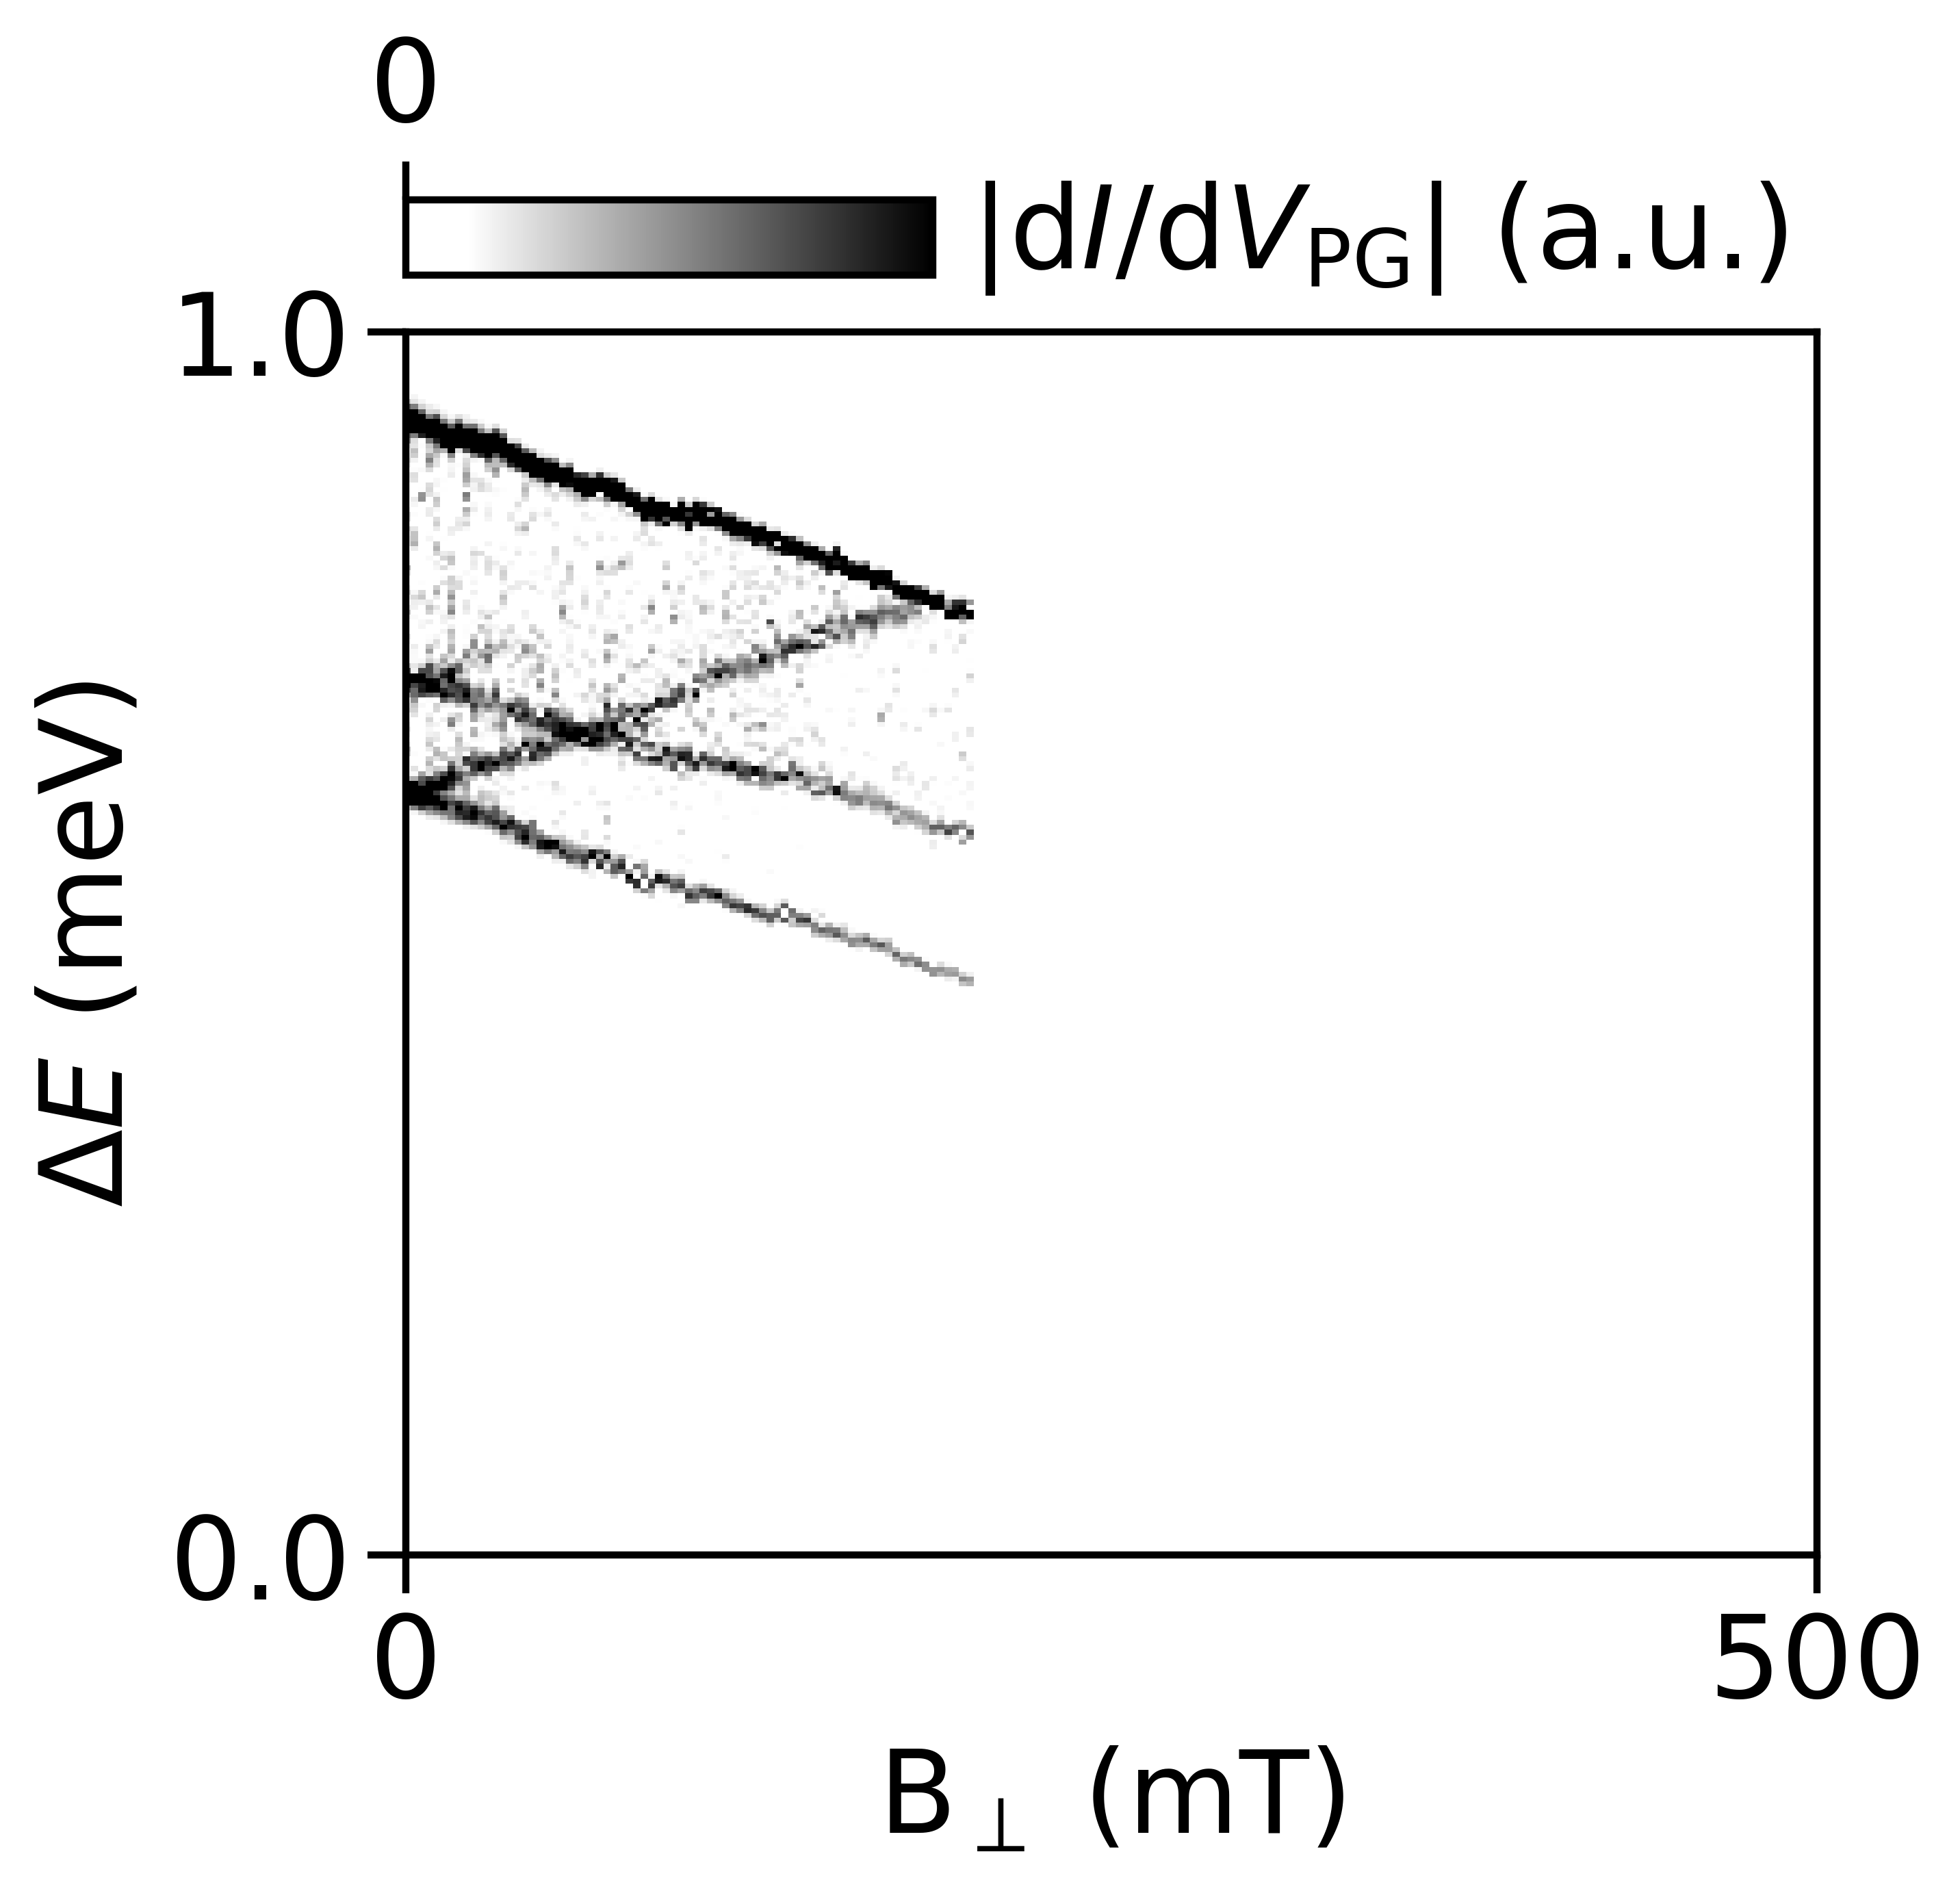

In [4]:
name='F0471_0to1_6VBG'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Tijl Degroote/Tijl Degroote/3 - Data/from Artem/%s.hdf5'%name
else:
    filename='N:/POBox/Tijl Degroote/Tijl Degroote/3 - Data/from Artem/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_PG=data['Data']['Data'][:,0,:]
# print(V_PGv)
Bz=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,3,:]*1e-8
# print(I_ACx)
# VSDAC=20e-6
# MG=data['Data']['Data'][:,3,:]
# SD=data['Data']['Data'][:,2,:]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Convert raw data to physical units
y_all = V_PG[:,0:81] *2 
x_all = Bz[:,0:81] * 1e3     # mT
z_all = I_ACx[:,0:81] * 1e9 # nA

dy = np.gradient(y_all, axis=0)  # Gives element-wise dy values

# Then compute the gradient of z_all along axis 0 (y-direction)
dz_dy = np.gradient(z_all, axis=0) / dy  # Element-wise division

# Choose a y value above which data should be shifted
y_jump_value = 0  # mT
x_shift = 0       # mV shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
# x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
y_range = (10.775, 10.815)  # in mV
x_range = (0, 500)      # in mT

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid edges for pcolormesh
x_centers = x_all[0, :]  # (126,), unique x values in mV
y_centers = y_all[:, 0]  # (1909,), unique y values in mT

# x_edges for regular spacing
step_x = x_centers[1] - x_centers[0]  # 0.8 mV
x_edges = np.linspace(x_centers[0] - step_x / 2, x_centers[-1] + step_x / 2, len(x_centers) + 1)

# y_edges for potentially irregular spacing
y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = 30

# Define colorbar ticks (optional)
cbar_ticks = [0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Create the pcolormesh plot
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(dz_dy), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=30), vmin=z_min, vmax=z_max)

# Set axis labels and limits
ax.set_xlabel(r'B$_\perp$ (mT)', labelpad=5)
ax.set_ylabel(r'$\Delta E$ (meV)', labelpad=5)
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.yaxis.set_major_locator(FixedLocator([10.775, 10.815]))  # Explicitly set y-ticks
ax.set_yticklabels(['0.0','1.0'])
ax.xaxis.set_major_locator(FixedLocator([0,500]))  # Explicitly set y-ticks



# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False,
                  labeltop=True, labelbottom=False)
cb.set_ticks(cbar_ticks)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{PG}|$ (a.u.)', va='center', ha='left', fontsize=24)

# Save the figure
folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "BLG_Electron_Positive_MS.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "BLG_Electron_Positive_MS.pdf"), format='pdf', bbox_inches='tight')
plt.show()

## TMD Weak electron positive

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD_DC', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'VSweep', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_CG1_C1', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C22C4_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C20C4_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C22C4_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C20C4_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_R', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_AC_R', b''), dtype=[('name',

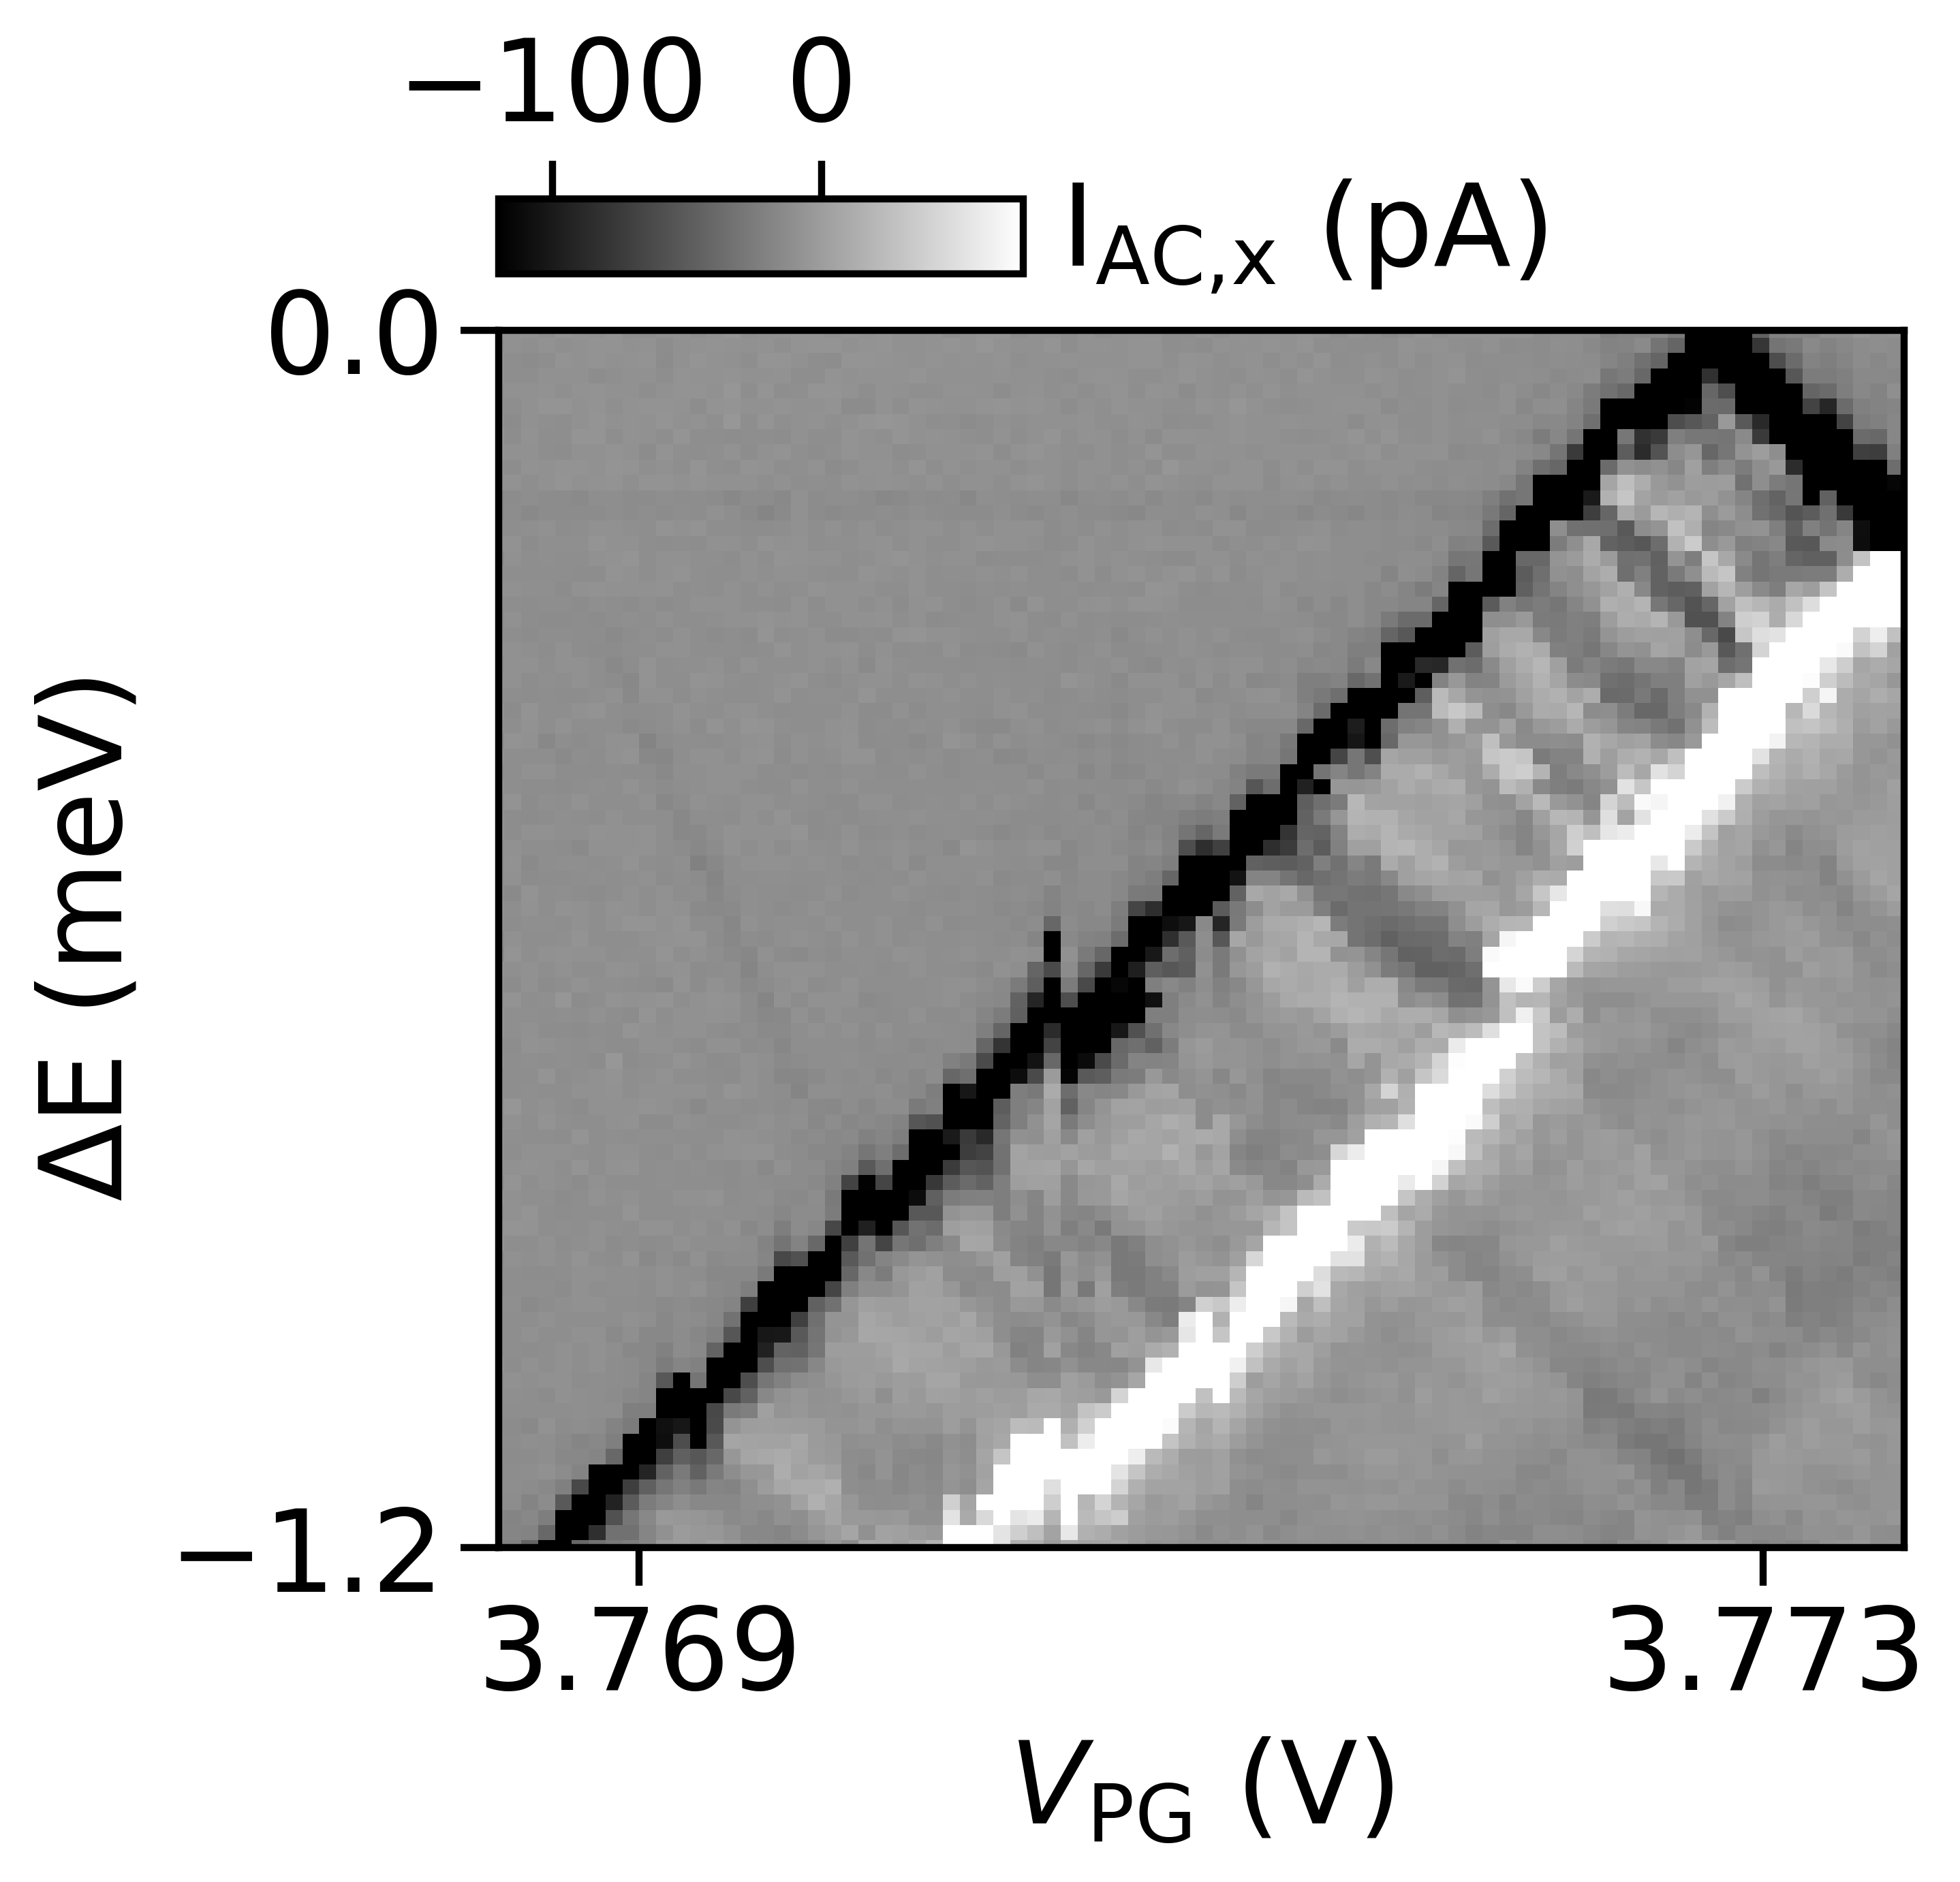

In [4]:
name='B301_JG18 _QD3_pnp_0T_diamond'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,2,:] *2
# print(Bz)
I_ACx=data['Data']['Data'][:,3,:]*1e-6

# Convert raw data to physical units
y_all = V_PG  # Gate 3 (V)
x_all = V_SD  # B⊥ (mT)
z_all = I_ACx * 1e12  # pA


# Choose a y value above which data should be shifted
y_jump_value = 0  # V (Gate 3)
x_shift = 0  # mT shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (3.7685, 3.7735)  # for Gate 3 (V)
y_range = (-1.2, 0)  # for B⊥ (mT)

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = -120
z_max = 75

# Define colorbar ticks
cbar_ticks = np.linspace(z_min, z_max, 3)  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, z_all, cmap='binary_r', vmin=z_min, vmax=z_max)
# ax.hlines(-0.1,np.min(x_edges)*0.99, np .max(x_edges)*1.01, colors='black', linestyles='dashed')
# Set labels and limits
ax.set_xlabel(r'$V_\text{PG}$ (V)', labelpad=5)
ax.set_ylabel(r'$\Delta$E (meV)', labelpad=5)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=2))
ax.xaxis.set_major_locator(FixedLocator([3.769, 3.773]))  # Explicitly set y-ticks
ax.yaxis.set_major_locator(FixedLocator([-1.2, 0.0]))  # Explicitly set y-ticks
# ax.xaxis.set_major_locator(FixedLocator([3.769,3.771,3.773]))  # Explicitly set y-ticks

# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)
cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'I$_\text{AC,x}$ (pA)', va='center', ha='left',fontsize=24)

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "Electron_Positive_Diamond.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "Electron_Positive_Diamond.pdf"), format='pdf', bbox_inches='tight')

plt.show()

In [5]:
# name='B302_JG18 _QD3_pnp_0T_perpcup'
# if MacBook == True:
#     filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
# else:
#     filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
# data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

# V_SD=data['Data']['Data'][:,0,:]
# # print(V_PGv)
# Bz=data['Data']['Data'][:,1,:]
# # print(Bz)
# I_ACx=data['Data']['Data'][:,3,:]*1e-8
# # print(I_ACx)
# # VSDAC=20e-6
# # MG=data['Data']['Data'][:,3,:]
# # SD=data['Data']['Data'][:,2,:]
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MaxNLocator

# # Convert raw data to physical units
# y_all = V_SD * 1e3 * 2  # mV
# x_all = Bz * 1e3     # mT
# z_all = I_ACx * 1e12 # pA

# # Choose a y value above which data should be shifted
# y_jump_value = 0  # mT
# x_shift = 0       # mV shift for y > y_jump_value

# # Shift the x values *before* filtering
# x_shifted = np.copy(x_all)
# # x_shifted[y_all > y_jump_value] += x_shift

# # Define the desired x and y range
# y_range = (300, 1400)  # in mV
# x_range = (0, 250)      # in mT

# # Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
# mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
#        (y_all >= y_range[0]) & (y_all <= y_range[1])

# # Compute grid edges for pcolormesh
# x_centers = x_all[0, :]  # (126,), unique x values in mV
# y_centers = y_all[:, 0]  # (1909,), unique y values in mT

# # x_edges for regular spacing
# step_x = x_centers[1] - x_centers[0]  # 0.8 mV
# x_edges = np.linspace(x_centers[0] - step_x / 2, x_centers[-1] + step_x / 2, len(x_centers) + 1)

# # y_edges for potentially irregular spacing
# y_diffs = np.diff(y_centers)
# y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
#                           (y_centers[:-1] + y_centers[1:]) / 2,
#                           [y_centers[-1] + y_diffs[-1] / 2]))

# # Set the min and max values for the colorbar
# z_min = -0.6
# z_max = 0.6

# # Define colorbar ticks (optional)
# cbar_ticks = np.linspace(z_min, z_max, 2)

# # Create figure
# fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# # Add axes for the pcolormesh plot
# ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# # Create the pcolormesh plot
# pcm = ax.pcolormesh(x_edges, -y_edges, z_all, cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=0), vmin=z_min, vmax=z_max)

# # Set axis labels and limits
# ax.set_xlabel(r'B$_\text{z}$ (mT)', labelpad=5)
# # ax.set_ylabel(r'SD Bias (mV)', labelpad=5)
# ax.set_xlim(x_range)
# ax.set_ylim(y_range)
# ax.yaxis.set_major_locator(FixedLocator([300, 1400]))  # Explicitly set y-ticks
# ax.xaxis.set_major_locator(FixedLocator([0,250]))  # Explicitly set y-ticks

# # Add colorbar above the plot
# cbar_ax = fig.add_axes([0.15, 0.83, 0.37, 0.04])  # Colorbar: 2/3 width
# cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
# cb.ax.tick_params(direction='out', which='major', top=True, bottom=False,
#                   labeltop=True, labelbottom=False)
# cb.set_ticks(cbar_ticks)
# cb.locator = MaxNLocator(nbins=1)
# cb.update_ticks()

# # Add colorbar label in a separate axes to the right of the colorbar
# label_ax = fig.add_axes([0.55, 0.825, 0.35, 0.05])  # Label: 1/3 width
# label_ax.axis('off')  # Hide axes
# label_ax.text(0, 0.5, r'I$_\text{AC,x}$ (pA)', va='center', ha='left', fontsize=22)

# # Save the figure
# folder = "Plots"
# os.makedirs(folder, exist_ok=True)
# plt.savefig(os.path.join(folder, "Electron_Positive_MS.png"), format='png', dpi=500, bbox_inches='tight')
# plt.savefig(os.path.join(folder, "Electron_Positive_MS.pdf"), format='pdf', bbox_inches='tight')
# plt.show()

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD_DC', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'magnet - Control / Field Setpoint Y', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_CG1_C1', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C22C4_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C20C4_AC_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_X', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C22C4_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_C20C4_AC_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_theta', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'dI_dVCH_R', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I

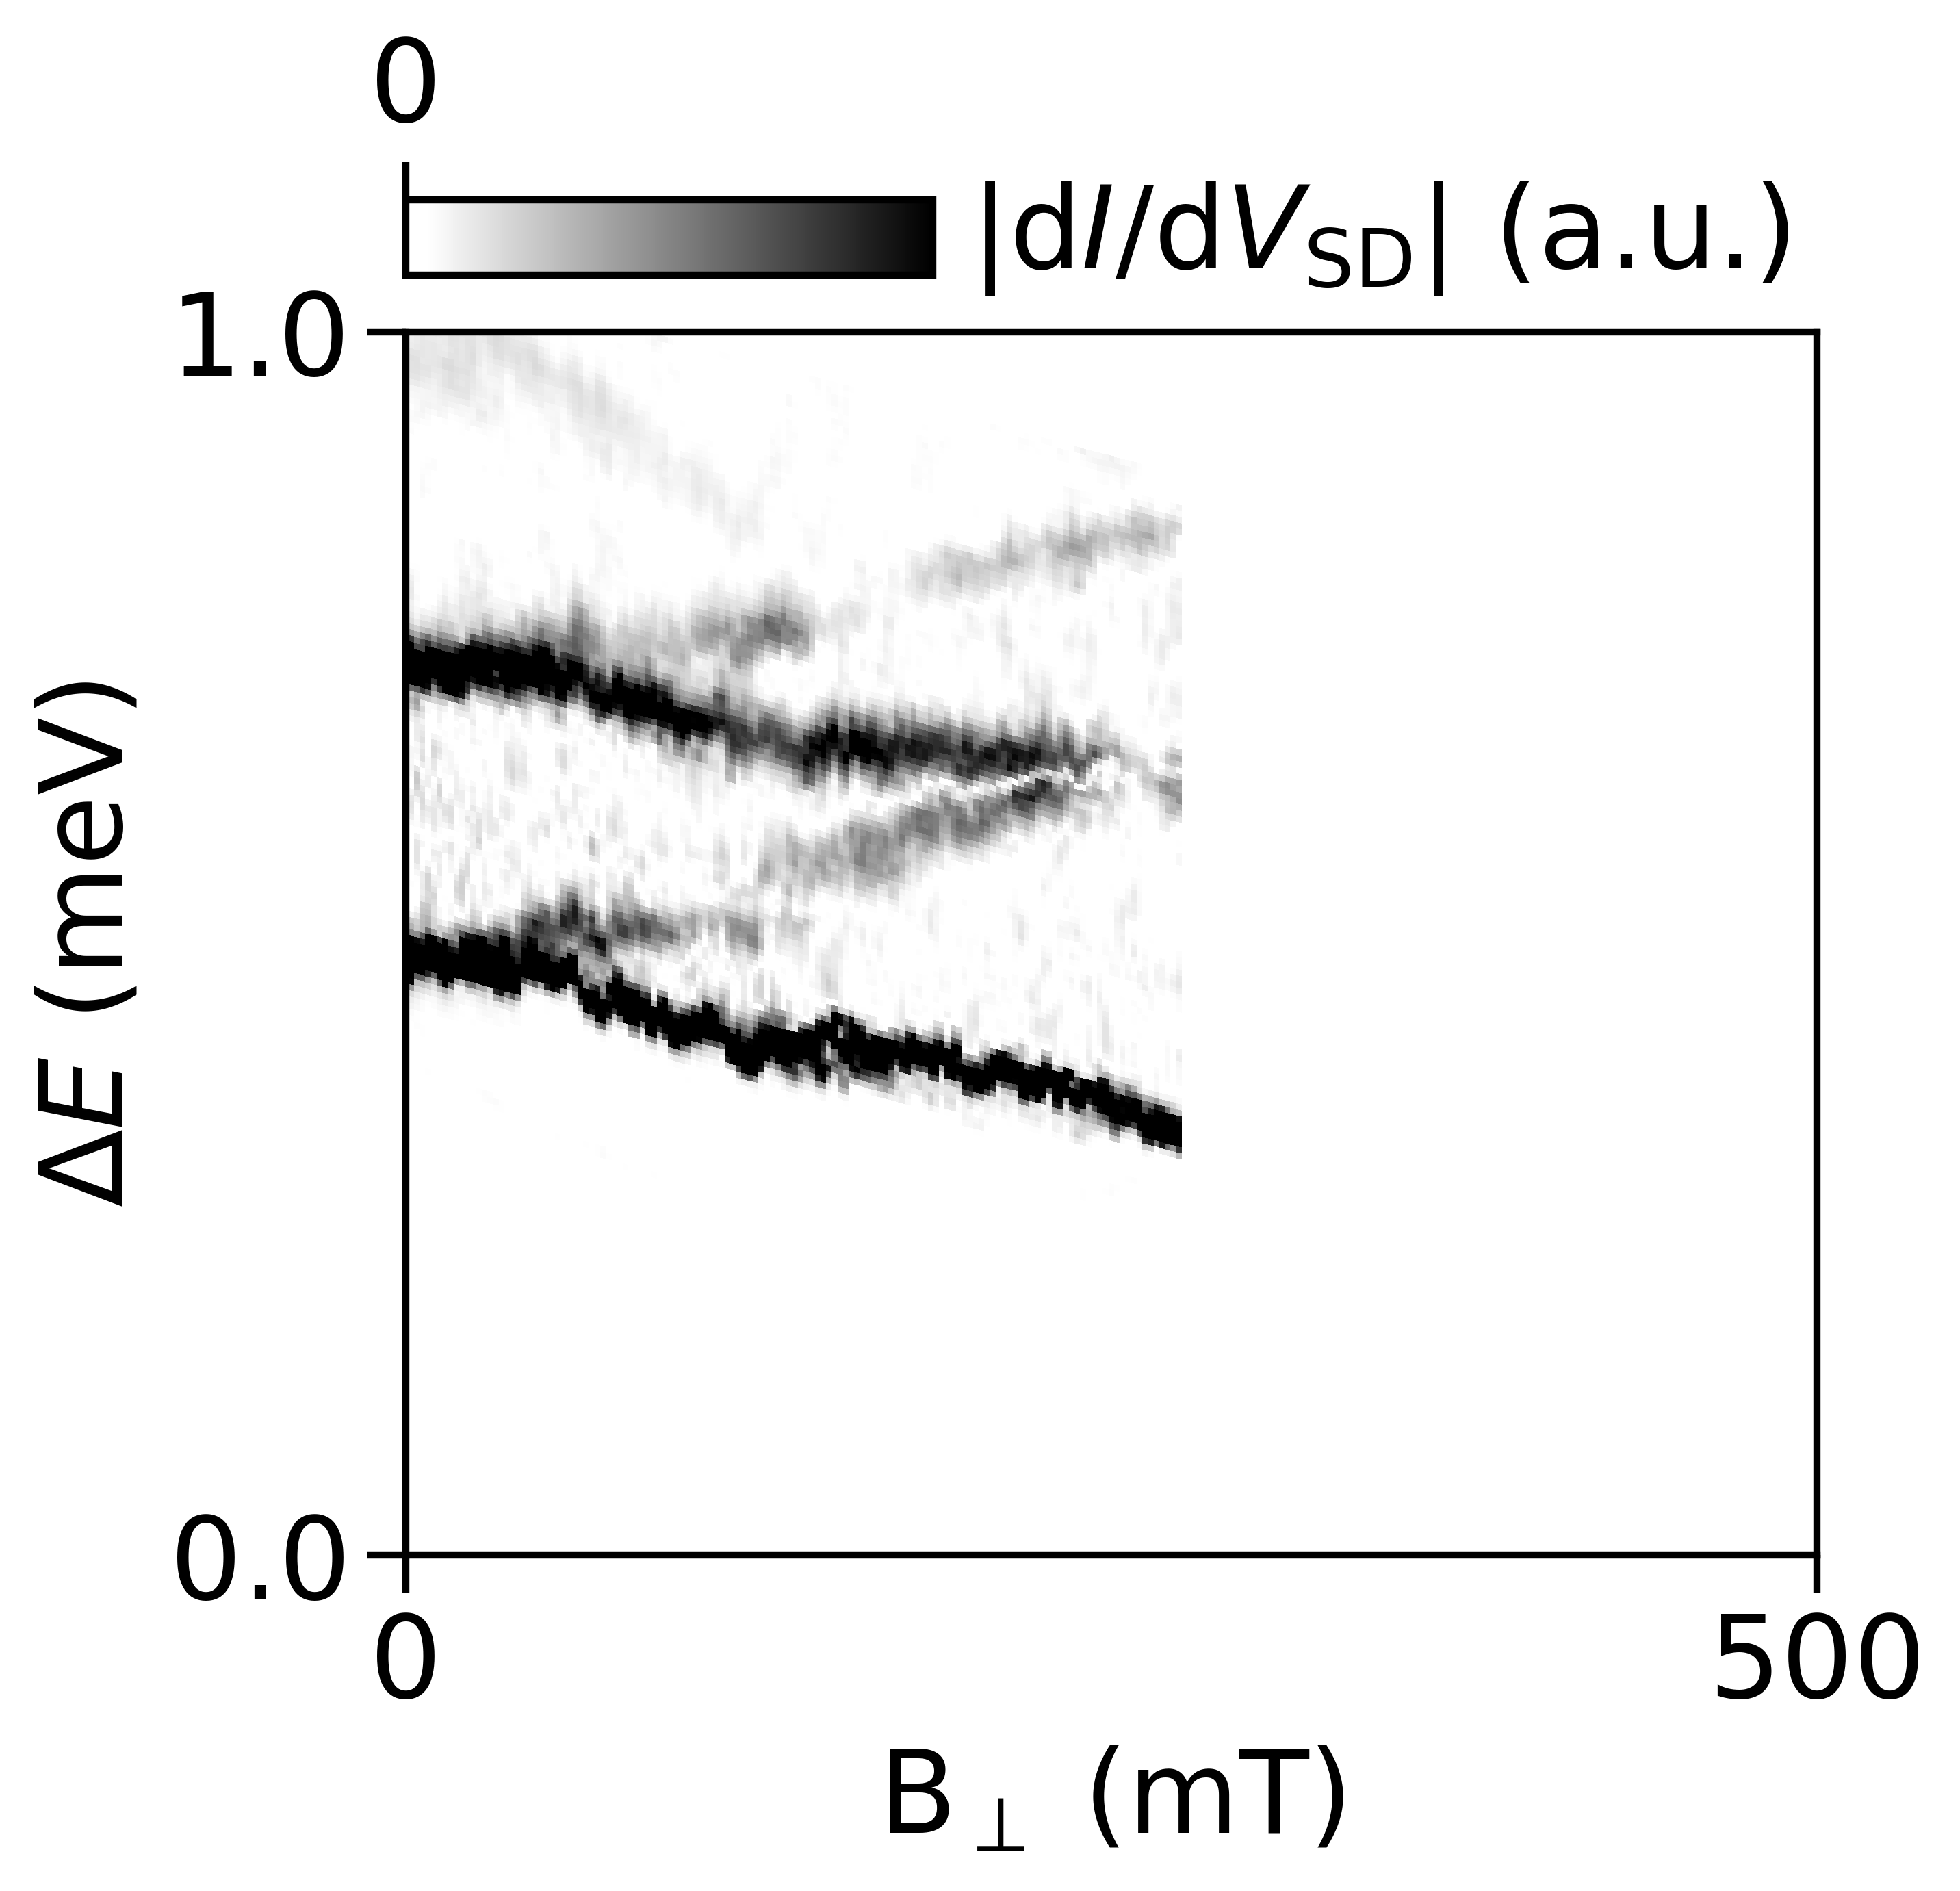

In [6]:
name='B302_JG18 _QD3_pnp_0T_perpcup'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/Stack18/Tabea_2024/2024/04/Data_0423/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,50:]/500/2
# print(V_PGv)
Bz=data['Data']['Data'][:,1,50:]
# print(Bz)
I_ACx=data['Data']['Data'][:,3,50:]*1e-7

VCG1 = data['Data']['Data'][:, 2, 50:]
# print(I_ACx)
# VSDAC=20e-6
# MG=data['Data']['Data'][:,3,:]
# SD=data['Data']['Data'][:,2,:]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

e2h = 3.8740459e-5  # e²/h in S
VSDAC = 10e-6       # Source-drain AC voltage

VSD_real = V_SD - (VCG1 - 1.885765) * 685.4e-6 / 2.224e-3
I_ACx = signal.savgol_filter(I_ACx, 2, 1, deriv=0, delta=1.0, axis=0, mode='interp')
I_ACx = signal.savgol_filter(I_ACx, 2, 1, deriv=0, delta=1.0, axis=1, mode='interp')

# Convert raw data to physical units
y_all = -VSD_real * 1e3 + 0.3 # mV 
x_all = Bz * 1e3     # mT
z_all = -I_ACx / VSDAC / e2h - 2.5e-3

# # Choose a y value above which data should be shifted
# y_jump_value = 0  # mT
# x_shift = 0       # mV shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
# x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
y_range = (0, 1)  # in mV
x_range = (0, 500)      # in mT

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
# mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
#        (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid edges for pcolormesh
x_centers = x_all[0, :]  # (126,), unique x values in mV
y_centers = y_all[:, 0]  # (1909,), unique y values in mT

# x_edges for regular spacing
step_x = x_centers[1] - x_centers[0]  # 0.8 mV
x_edges = np.linspace(x_centers[0] - step_x / 2, x_centers[-1] + step_x / 2, len(x_centers) + 1)

# y_edges for potentially irregular spacing
y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = 0.030

# Define colorbar ticks (optional)
cbar_ticks = [0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Create the pcolormesh plot
pcm = ax.pcolormesh(x_all, y_all, np.abs(z_all), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=10), vmin=z_min, vmax=z_max)

# Set axis labels and limits
ax.set_xlabel(r'B$_\perp$ (mT)', labelpad=5)
ax.set_ylabel(r'$\Delta E$ (meV)', labelpad=5)
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.yaxis.set_major_locator(FixedLocator([0,1.0]))  # Explicitly set y-ticks
ax.set_yticklabels(['0.0','1.0'])
ax.xaxis.set_major_locator(FixedLocator([0,500]))  # Explicitly set y-ticks

# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False,
                  labeltop=True, labelbottom=False)
cb.set_ticks(cbar_ticks)
# cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{SD}|$ (a.u.)', va='center', ha='left', fontsize=24)

# Save the figure
folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "Electron_Positive_MS.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "Electron_Positive_MS.pdf"), format='pdf', bbox_inches='tight')
plt.show()

## TMD Weak electron negative

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD Left C18 C6', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'PG Virtual', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_MG C17', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_PG Left C24', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_SD Left C18', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC x', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC theta', b''), dtype=[('name', 'O'), ('info', 'O')])]


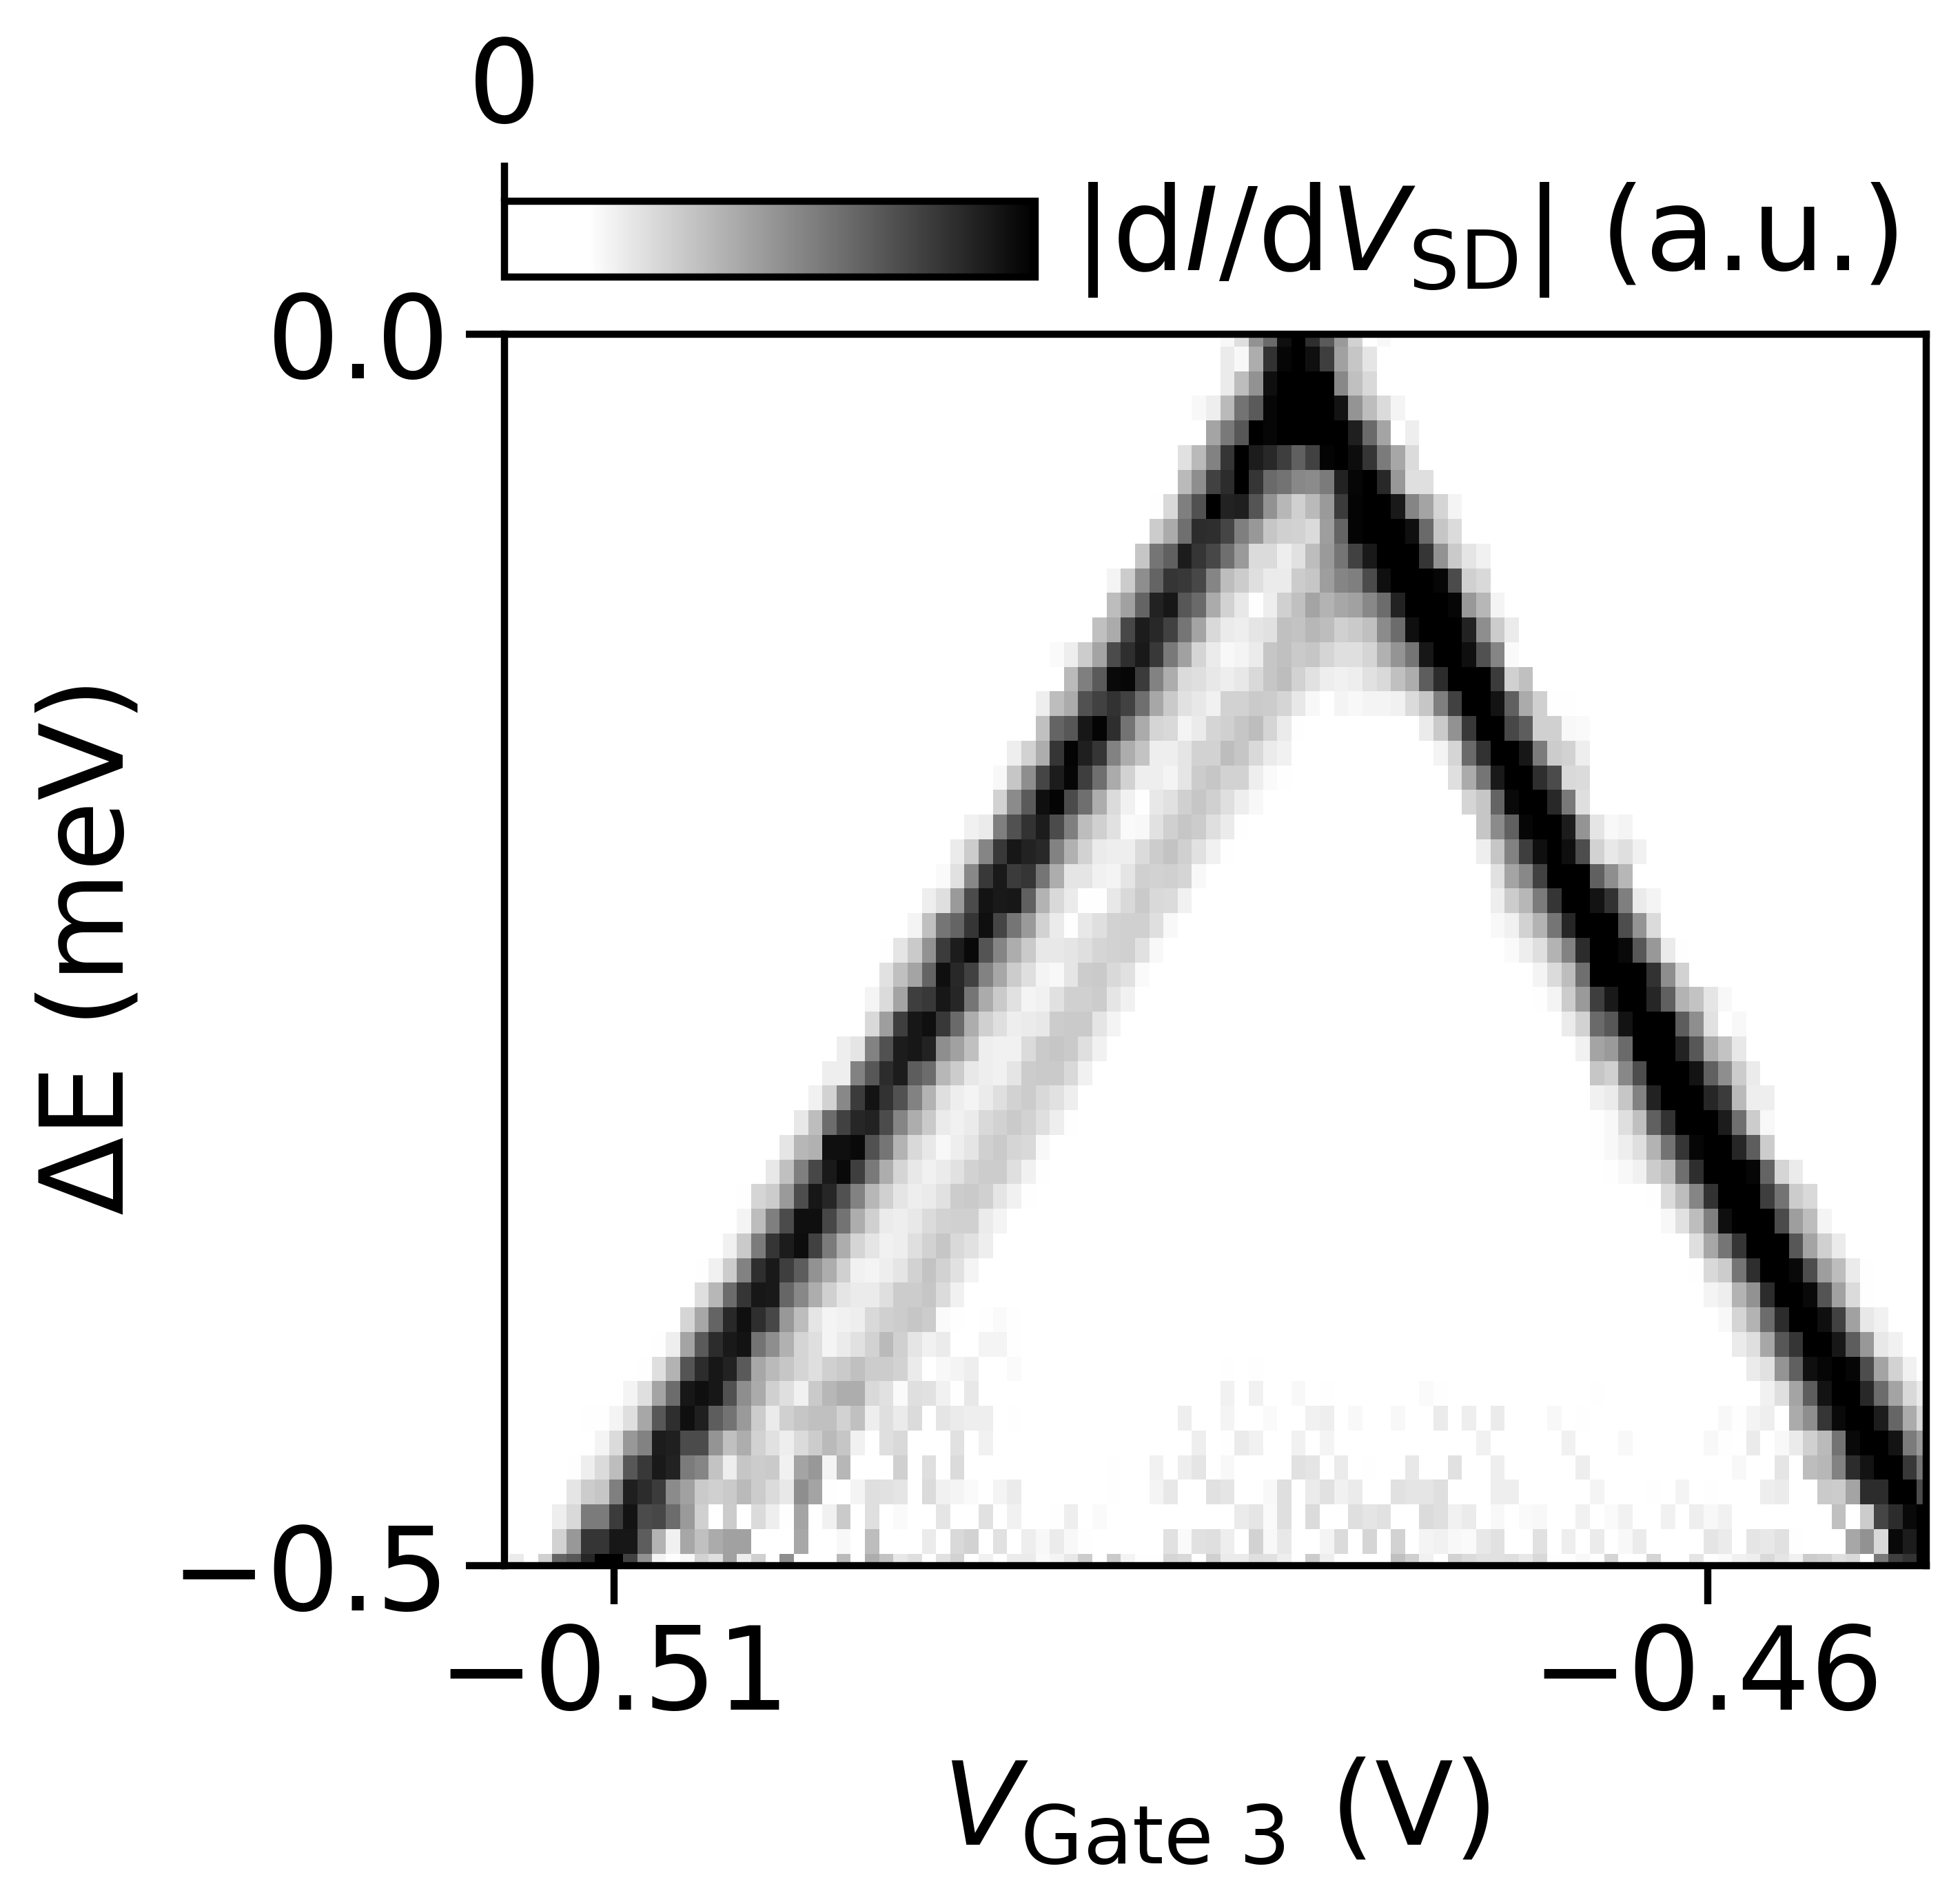

In [4]:
name='C0062 4VBGm 1e Diamond MG'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,5,:]*1e-8

V_AC = 50e-6

# Convert raw data to physical units
y_all = V_PG[:, 0:101]  # Gate 3 (V)
x_all = V_SD[:, 0:101]  # B⊥ (mT)
z_all = I_ACx[:, 0:101] * 1e9 / V_AC # nA/uV

# Choose a y value above which data should be shifted
y_jump_value = 0  # V (Gate 3)
x_shift = 0  # mT shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (-0.515, -0.450)  # for Gate 3 (V)
y_range = (-0.5, 0)  # for B⊥ (mT)

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = 600

# Define colorbar ticks
cbar_ticks = [0]  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(z_all), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=40), vmin=z_min, vmax=z_max)
# ax.hlines(-0.1,np.min(x_edges)*0.99, np .max(x_edges)*1.01, colors='black', linestyles='dashed')
# Set labels and limits
ax.set_xlabel(r'$V_\text{Gate 3}$ (V)', labelpad=5)
ax.set_ylabel(r'$\Delta$E (meV)', labelpad=5)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
ax.yaxis.set_major_locator(FixedLocator([-0.5, 0]))  # Explicitly set y-ticks
ax.xaxis.set_major_locator(FixedLocator([-0.51,-0.46]))  # Explicitly set y-ticks


# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)
cb.set_ticks(cbar_ticks)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{SD}|$ (a.u.)', va='center', ha='left',fontsize=24)

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "Electron_Negative_Diamond.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "Electron_Negative_Diamond.pdf"), format='pdf', bbox_inches='tight')
plt.show()

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'PG Virtual', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'Magnet - B', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_SD Left C18 C6', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_MG C17', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_PG Left C24', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_SD Left C18', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC x', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC theta', b''), dtype=[('name', 'O'), ('info', 'O')])]


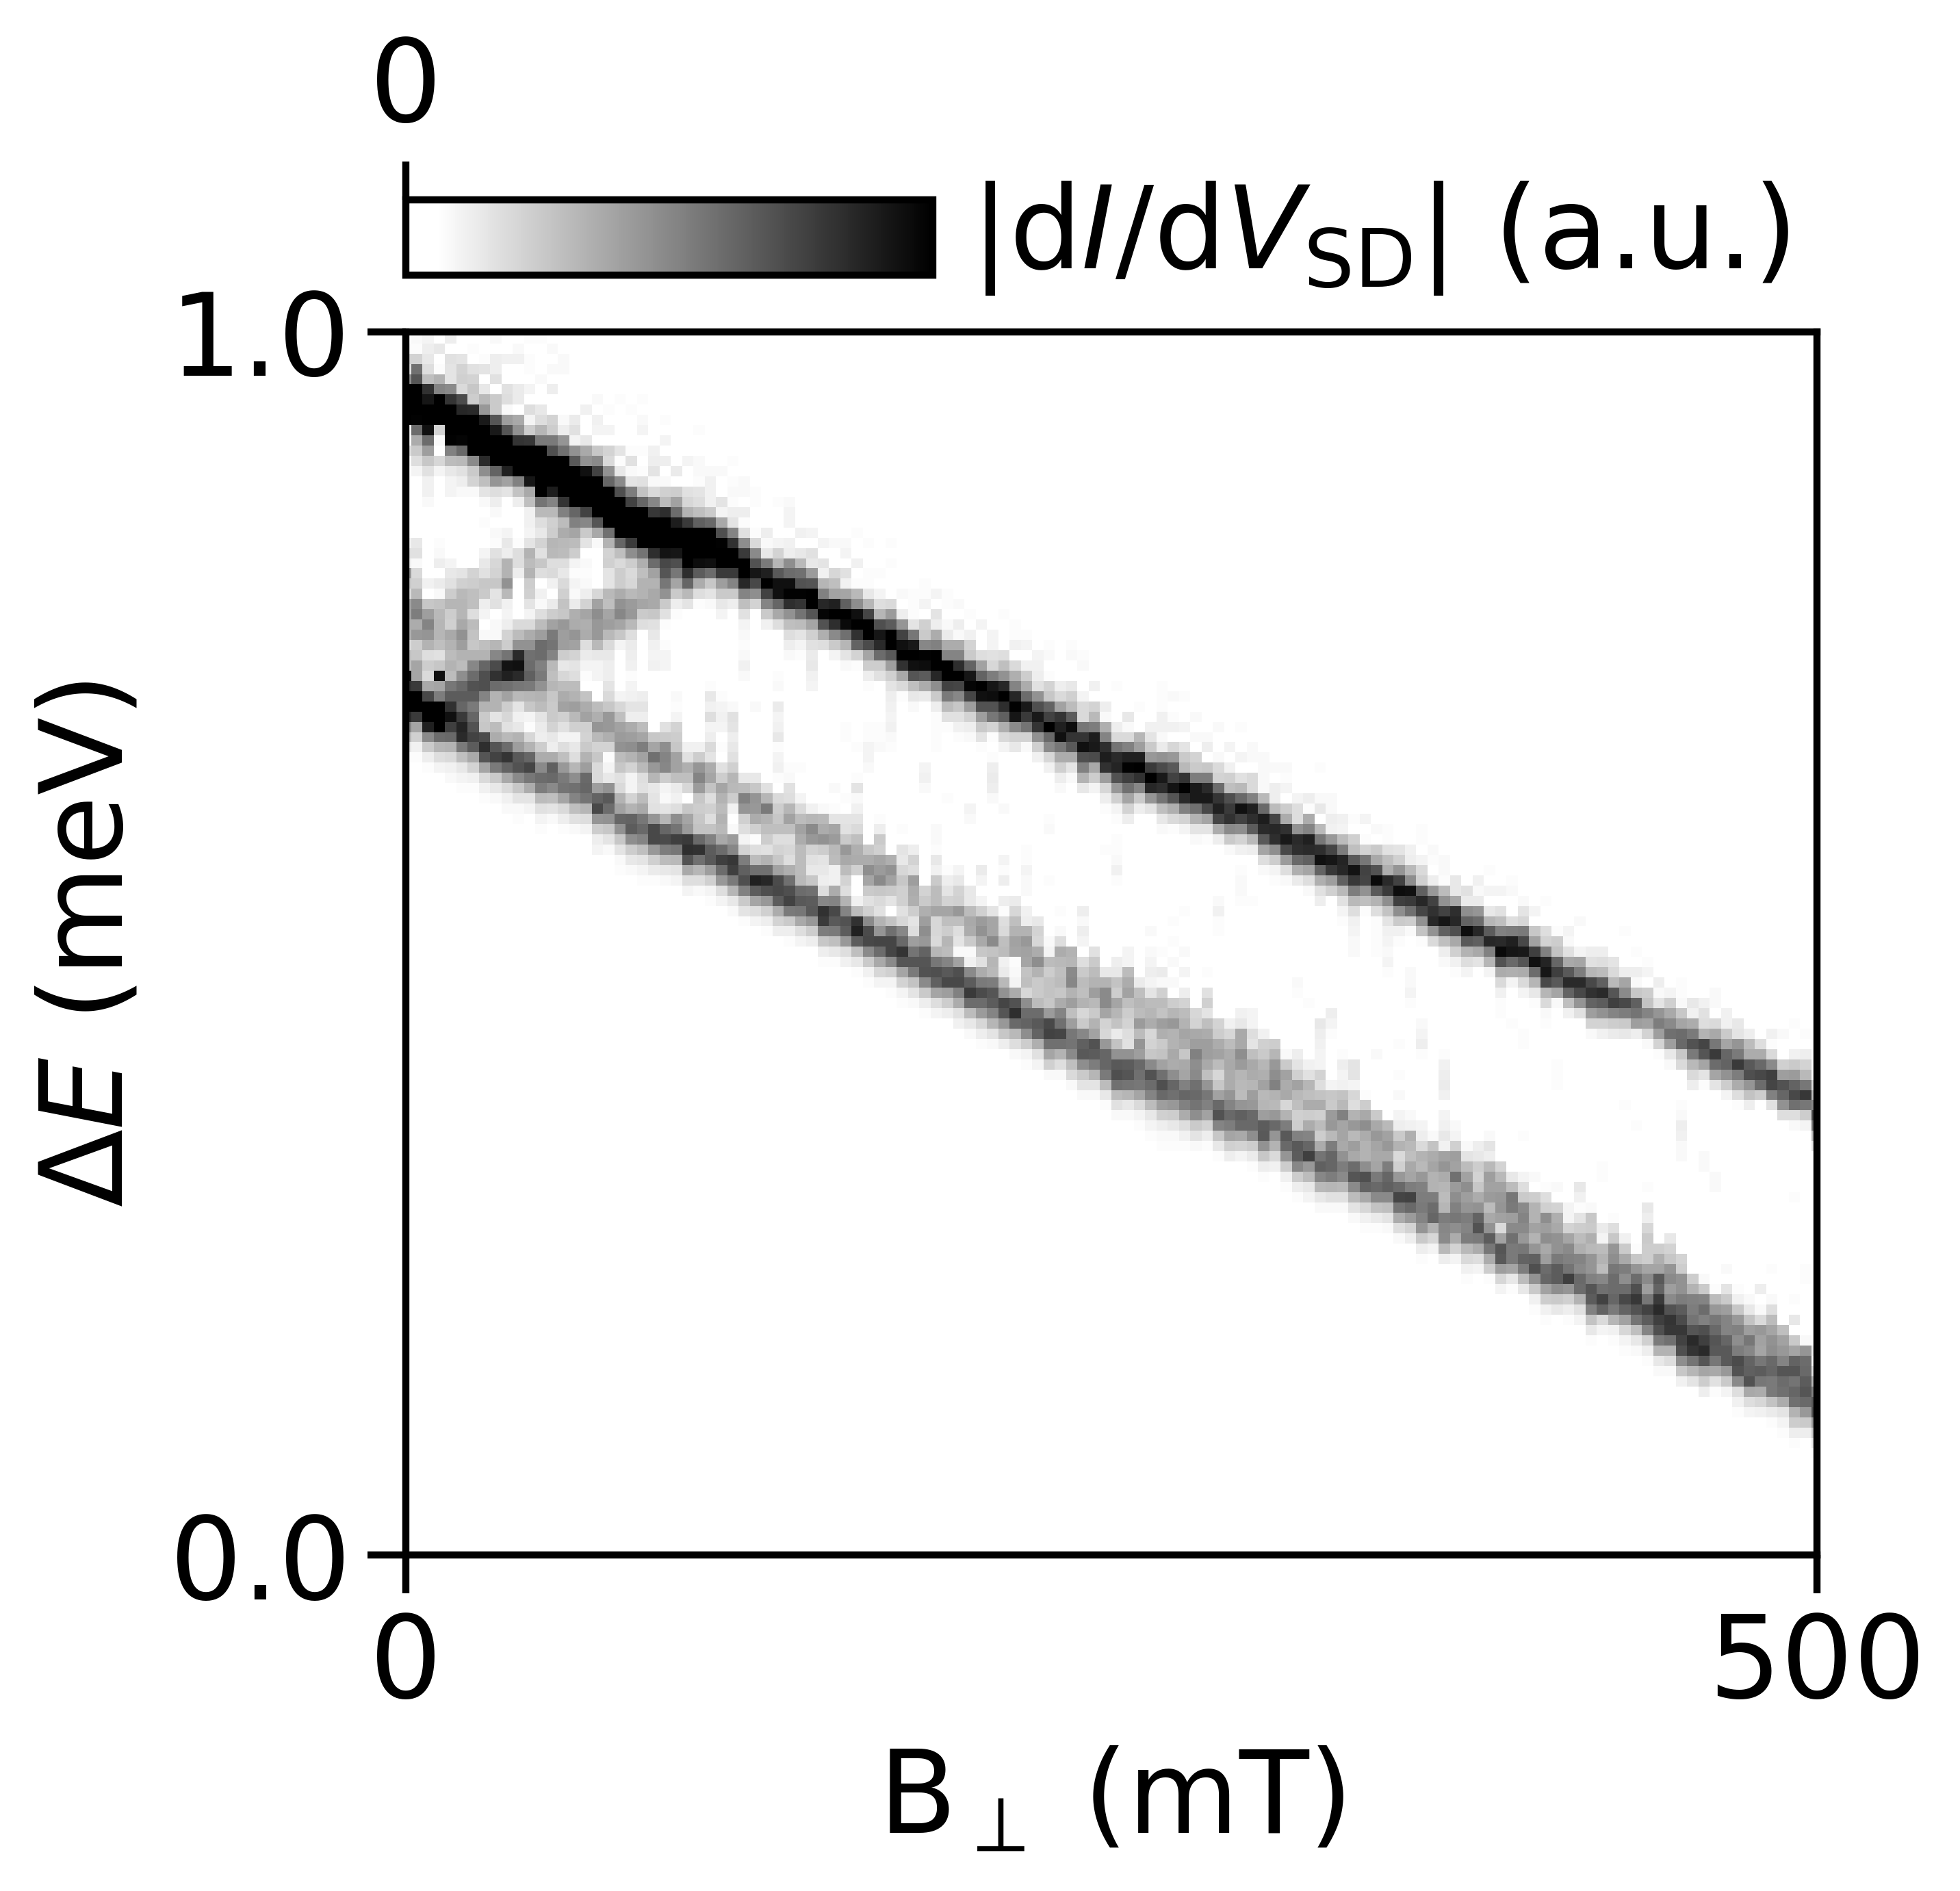

In [8]:
name='C0058 4VBGm 1e PG BField MGs'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0715/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0715/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])
V_PGv=data['Data']['Data'][:,0,:]
# print(V_PGv)
Bz=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,6,:]*1e-8
# print(I_ACx)
# VSDAC=20e-6
MG=data['Data']['Data'][:,3,:]
SD=data['Data']['Data'][:,2,:]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

lever_arm = 1/95.7
V_AC = 50e-6

# Convert raw data to physical units
y_al = V_PGv[:,0:251] * 1e3 * lever_arm  # mV
y_all = y_al - np.min(y_al)
x_all = Bz[:,0:251] * 1e3     # mT
z_all = I_ACx[:,0:251] * 1e9 / V_AC # nA/uV

# Choose a y value above which data should be shifted
y_jump_value = 0  # mT
x_shift = 0       # mV shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
y_range = (0, 1)  # in mV
x_range = (0, 500)      # in mT

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid edges for pcolormesh
x_centers = x_all[0, :]  # (126,), unique x values in mV
y_centers = y_all[:, 0]  # (1909,), unique y values in mT

# x_edges for regular spacing
step_x = x_centers[1] - x_centers[0]  # 0.8 mV
x_edges = np.linspace(x_centers[0] - step_x / 2, x_centers[-1] + step_x / 2, len(x_centers) + 1)

# y_edges for potentially irregular spacing
y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0 
z_max = 500

# Define colorbar ticks (optional, change as needed)
cbar_ticks = [0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the main plot
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh
pcm = ax.pcolormesh(x_edges, y_edges, z_all, cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=15), vmin=z_min, vmax=z_max)

# Axis labels and limits
ax.set_xlabel(r'B$_\perp$ (mT)', labelpad=5)
ax.set_ylabel(r'$\Delta E$ (meV)', labelpad=5)
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.yaxis.set_major_locator(FixedLocator([0, 1]))  # Explicitly set y-ticks
ax.set_yticklabels(['0.0', '1.0'])
ax.xaxis.set_major_locator(FixedLocator([0,500]))  # Explicitly set y-ticks

# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False,
                  labeltop=True, labelbottom=False)
cb.set_ticks(cbar_ticks)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{SD}|$ (a.u.)', va='center', ha='left',fontsize=24)
# Save the figure
folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "Electron_Negative_MS.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "Electron_Negative_MS.pdf"), format='pdf', bbox_inches='tight')
plt.show()

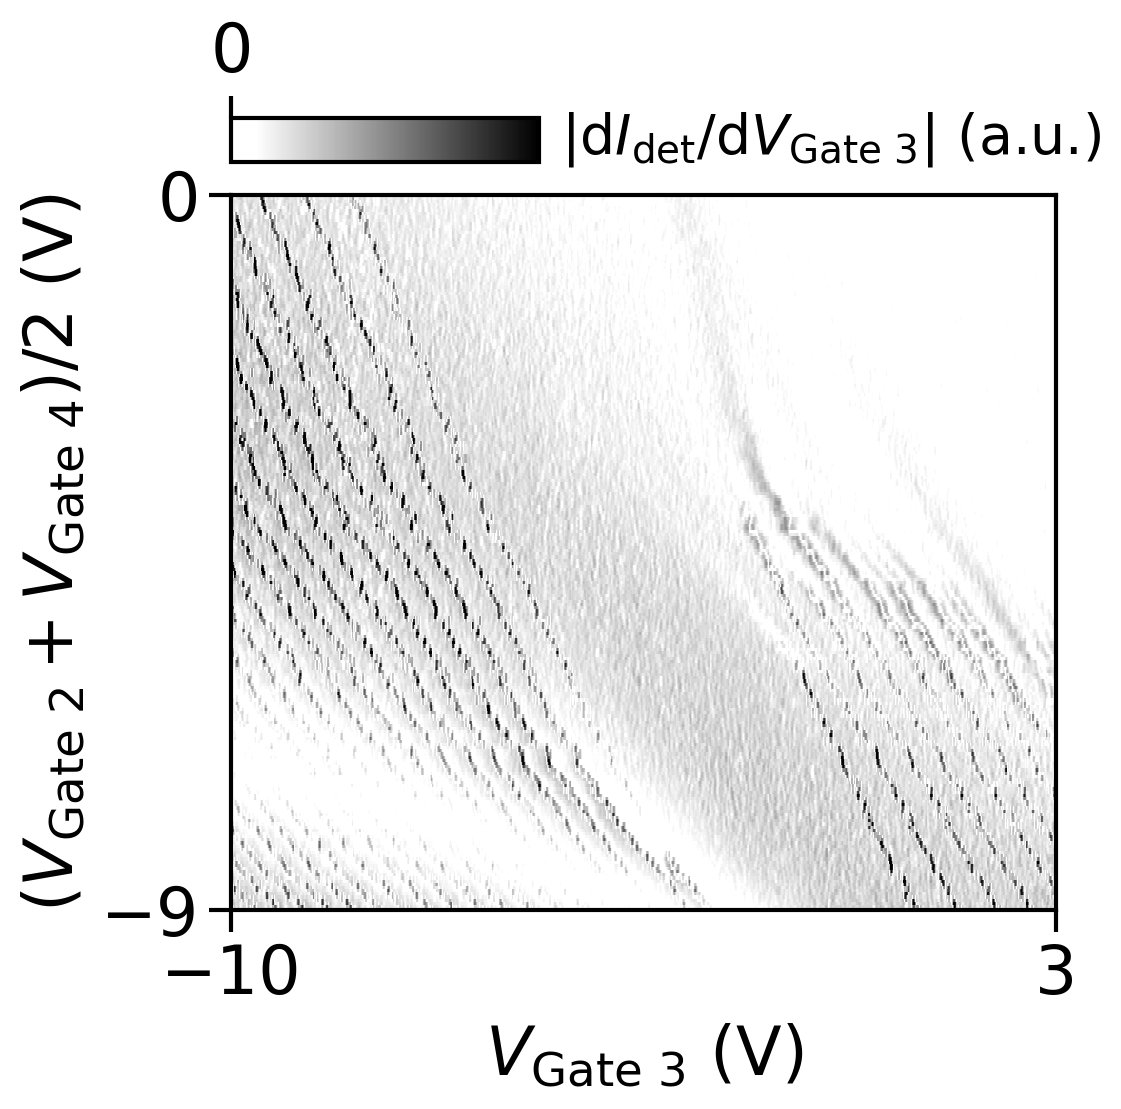

In [5]:
name='B0635 6VBG Charge det PG barier'
if MacBook == True:
    filename='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/05/Data_0520/%s.hdf5'%name
else: 
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/05/Data_0520/%s.hdf5'%name
data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

V_PG=data['Data']['Data'][:,0,:]*2
FG2=data['Data']['Data'][:,2,:]*2
FG22=data['Data']['Data'][:,1,:]*2
I_dot=data['Data']['Data'][:,3,:]*1e-8
I_det=data['Data']['Data'][:,4,:]*1e-8

# Convert raw data to physical units
x_all = V_PG 
y_all = (FG2 + FG22)/2 -0.25
z_all = I_det * 1e9 # nA

e2h = 3.8740459e-5  # e²/h in S
VSDAC = 10e-6       # Source-drain AC voltage


Igradient = np.gradient(I_det, axis=0) / VSDAC / e2h

Igradient = signal.savgol_filter(Igradient, 3, 1, deriv=0, delta=1.0, axis=0, mode='interp', cval=0.0)
Igradient = signal.savgol_filter(Igradient, 3, 1, deriv=0, delta=1.0, axis=1, mode='interp', cval=0.0)
z_all = Igradient

# Define the desired x and y range
x_range = (-10, 3)  # for Gate 3 (V)
y_range = (-9, 0)  # for B⊥ (mT)


# Compute grid centers
x_centers = x_all[:,0]  # Unique Gate 3 values (assuming constant along columns)
y_centers = y_all[0,:]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = max(abs(np.min(z_all)), np.max(z_all)) * 0.4

# Define colorbar ticks
cbar_ticks = [0]  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=200)

# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(z_all.T), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=20), vmin=z_min, vmax=z_max)
# ax.hlines(-0.1,np.min(x_edges)*0.99, np .max(x_edges)*1.01, colors='black', linestyles='dashed')
# Set labels and limits
ax.set_xlabel(r'$V_\text{Gate 3}$ (V)', labelpad=5)
ax.set_ylabel(r'$(V_\text{Gate 2}+V_\text{Gate 4})/2$ (V)', labelpad=5)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
ax.yaxis.set_major_locator(FixedLocator([-9,0]))  # Explicitly set y-ticks
ax.xaxis.set_major_locator(FixedLocator([-10,3]))  # Explicitly set y-ticks


# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)

cb.ax.set_xticks([0])

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'|d$I_\text{det}/$d$V_\text{Gate 3}|$ (a.u.)', va='center', ha='left', fontsize=20)

folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "ChargeSesning.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "ChargeSesning.pdf"), format='pdf', bbox_inches='tight')

plt.show()

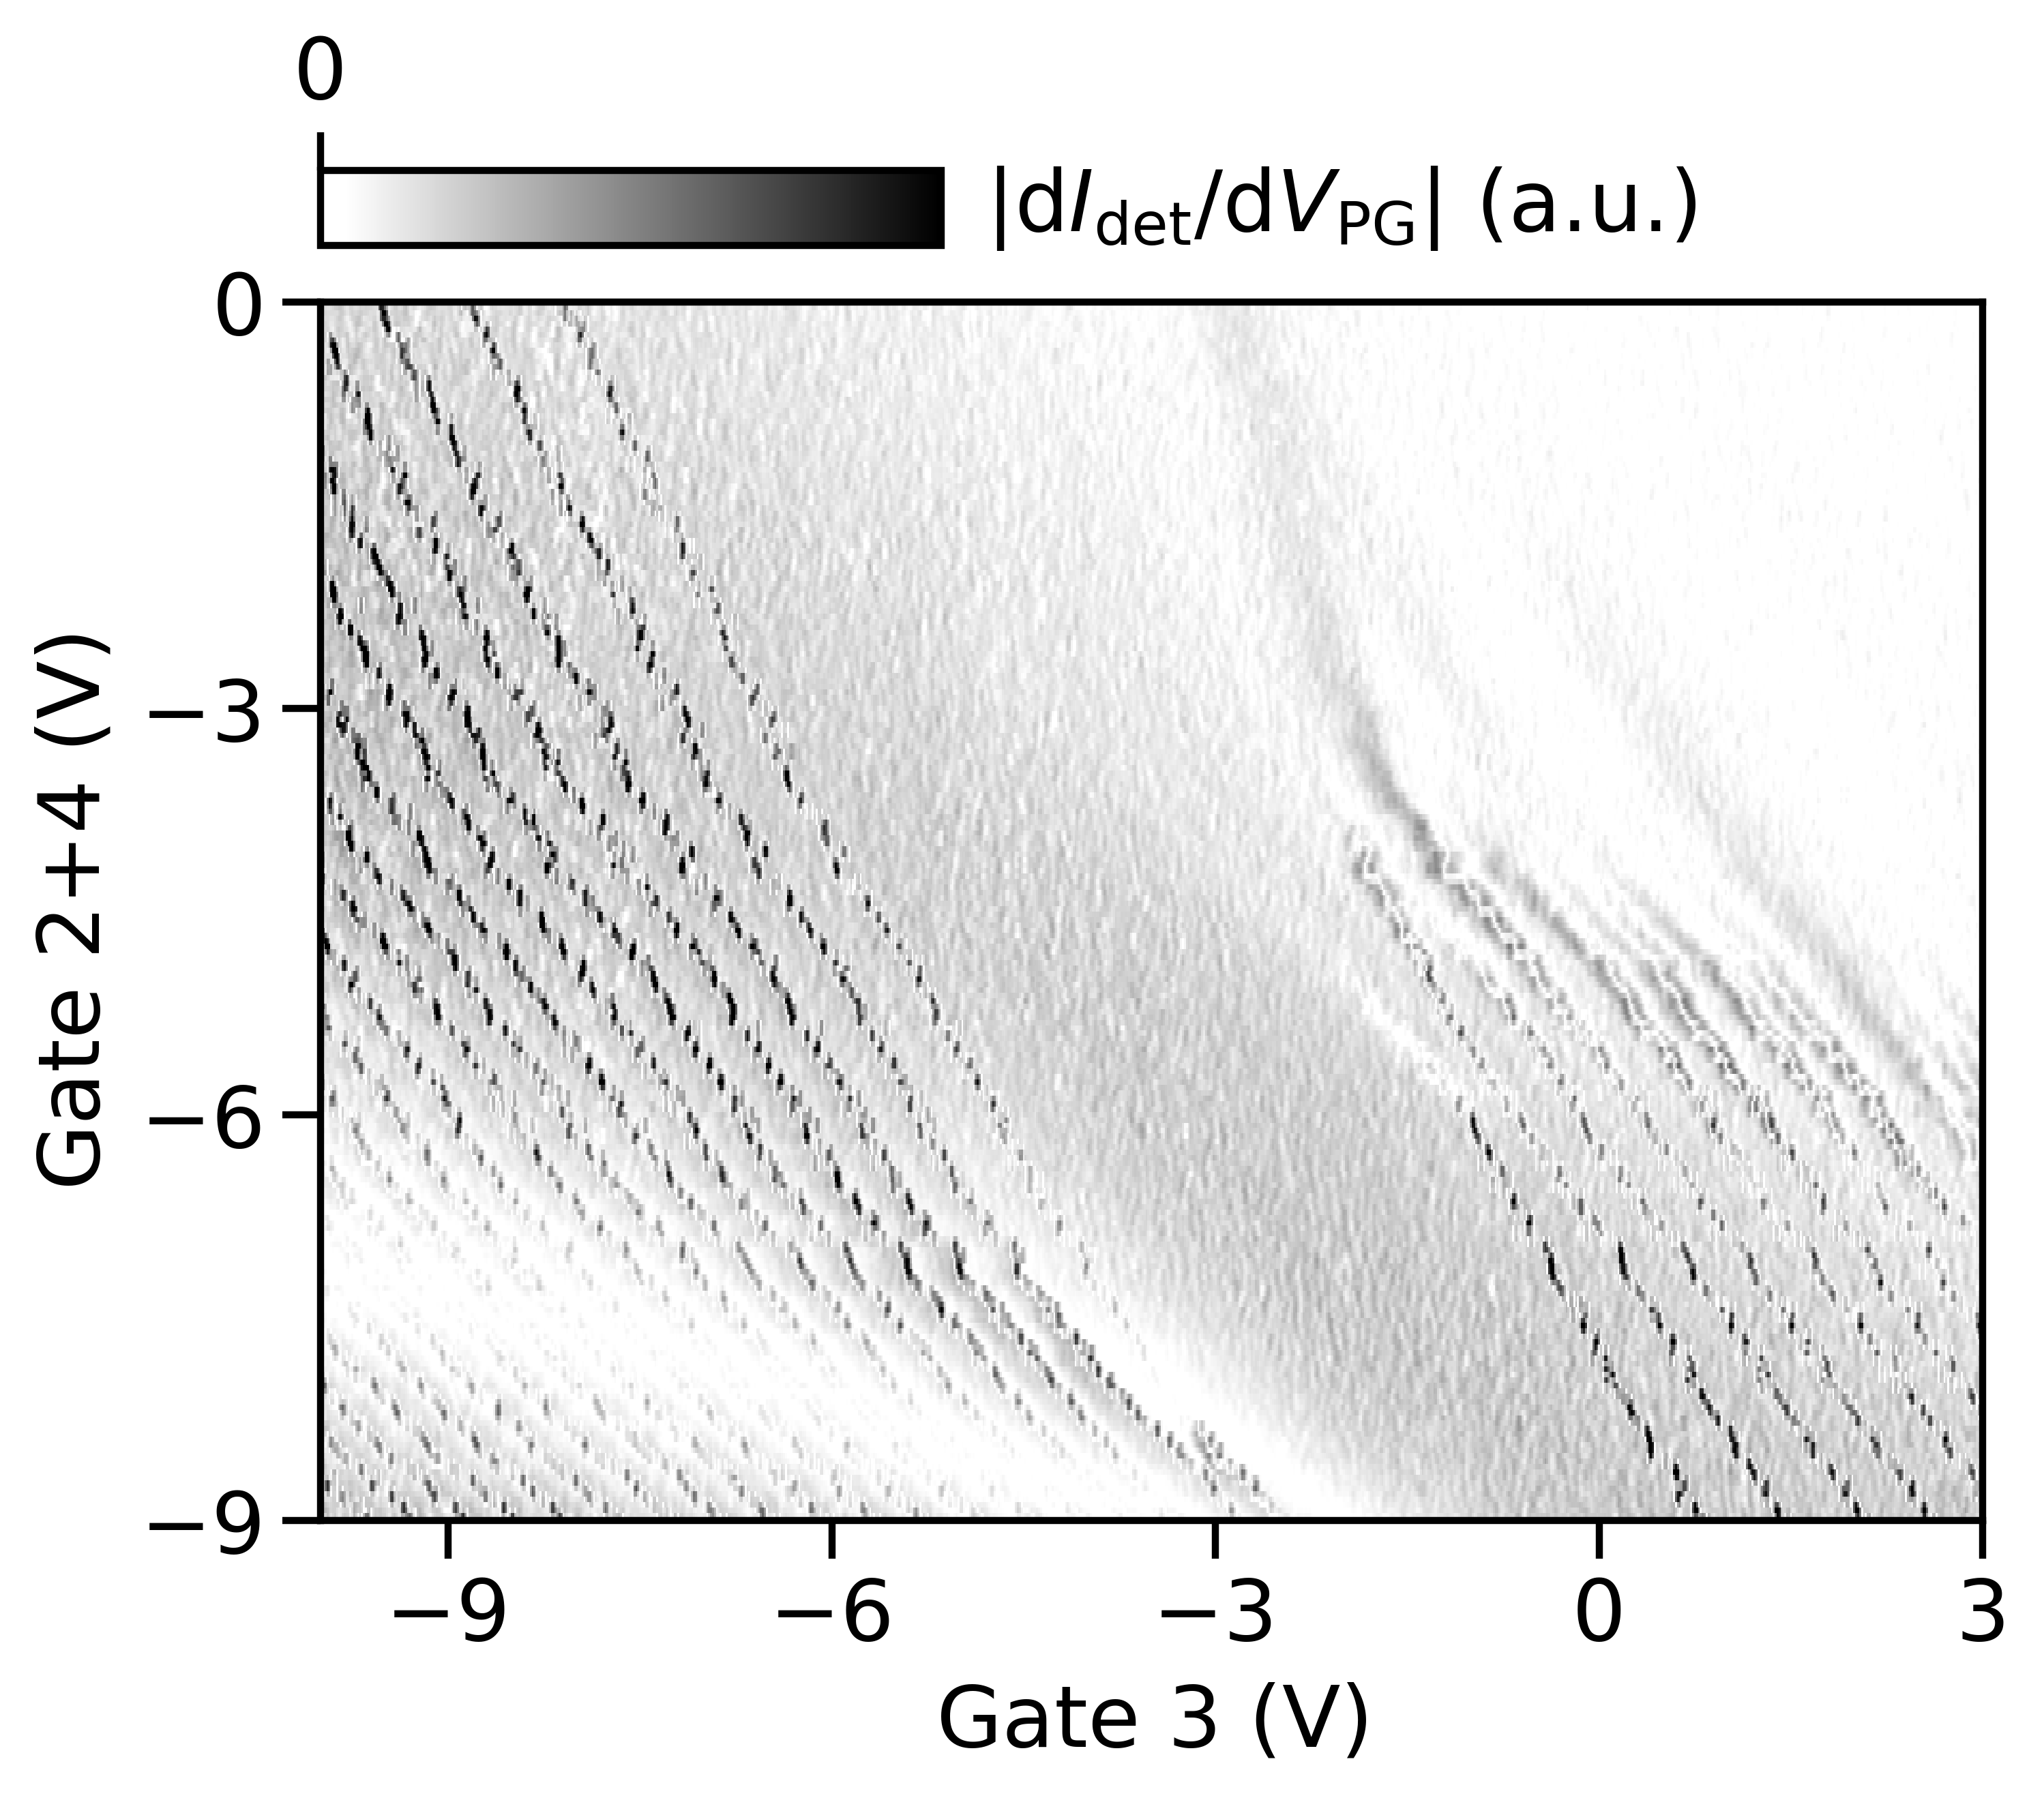

## Displacement Field SO Gaps

In [112]:
# [dipl. field in V/nm, SO gap, SO error]
# weak in ueV
# strong in meV

A_weak_h = [[0.5676,107.28,55/2], [0.4927,+131.10,88/2], [0.4132,+173.99,80/2], [0.3344,184.21,89/2], [0.2562,182.62,41/2], [0.1789,+221.22,42/2]]
A_weak_e = [[-0.3256,205.75,0],[-0.2467,248.42,0],[-0.1702,288.63,0]]

B_strong_h = [[0.7033,1.41749,0.02], [0.5474,1.41946,0.02], [0.3928,1.45471,0.02], [0.264,1.48055,0.02]] 
B_strong_e = [[-0.6182,1.27319,0.017171]]

C_weak_e = [[-0.16,-86,10]]
C_strong_h = [[-0.16, -1.650,0]] #errors to do!

D_weak_h = [[-0.3186,-150,0]] #errors to do!
D_weak_e = [[0.5506,-78,0], [0.4172,-76,0], [0.2848,-73,0]] #errors to do!
D_strong_h = [[0.3977,-1.56,0]] #errors to do!
D_strong_e = [[-0.3186,-1.36,0]] #errors to do!


textsize = 20

C:\Users\User\AppData\Local\Temp\ipykernel_21880\3370057536.py:44: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry


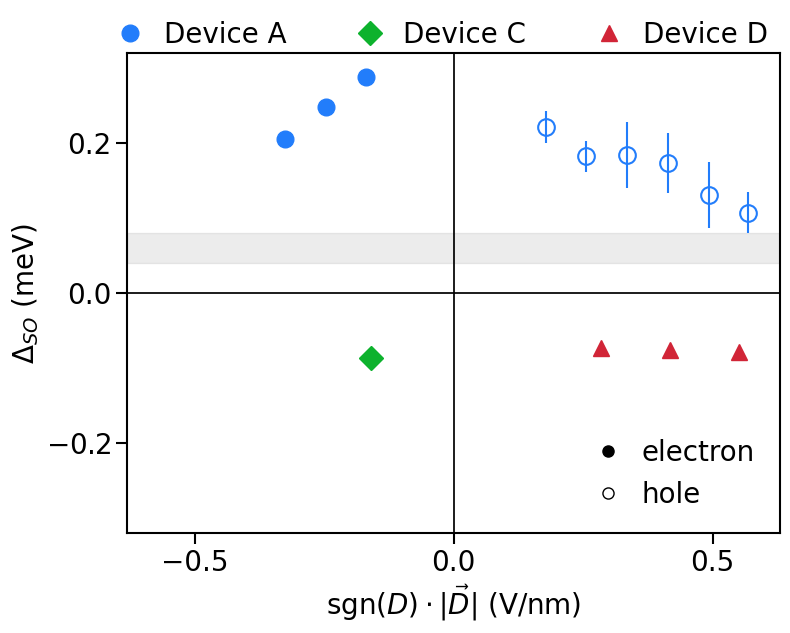

In [113]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Function to plot data
def plot_data(ax, data, marker, facecolor, edgecolor, label=None):
    for point in data:
        D, delta_SO, err = point
        
        # If the marker is empty, set thicker edge
        mew = 1.5 if facecolor == 'none' else 1.0  # adjust thickness as you like
        
        eb = ax.errorbar(
            D, delta_SO, yerr=err if err != 0 else None, fmt=marker,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            ecolor=edgecolor,
            markersize=12,
            markeredgewidth=mew,  # <-- set edge width here
            label='_nolegend_'  # Prevent error bars in legend
        )
        if label:
            eb[0].set_label(label)
            label = None

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot A
plot_data(ax, A_weak_h, 'o', facecolor='none', edgecolor=custom_blue, label='')
plot_data(ax, A_weak_e, 'o', facecolor=custom_blue, edgecolor=custom_blue, label='Device A')

# Plot C
plot_data(ax, C_weak_e, 'D', facecolor=custom_green, edgecolor=custom_green, label='Device C')

# Plot D
# plot_data(ax, D_weak_h, 'o', facecolor='none', edgecolor=custom_red, label='')
plot_data(ax, D_weak_e, '^', facecolor=custom_red, edgecolor=custom_red, label='Device D')

ax.axhline(0, color='black', linewidth=1.25, linestyle='-')  # horizontal line at Δ_SO = 0
ax.axvline(0, color='black', linewidth=1.25, linestyle='-')  # vertical line at D = 0


# Add gray band between 40 and 80 μeV
ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry

# Custom legend handles for electron and hole markers
electron_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markerfacecolor='black', markeredgecolor='black', markersize=8, label='electron')
hole_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black', markersize=8, label='hole')

# Get existing legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Add electron and hole marker to legend
handles.extend([electron_handle, hole_handle])
labels.extend(['electron', 'hole'])

# Finalize plot
ax.set_xlabel(r"sgn$(D)\cdot |\vec{D}|$ (V/nm)",fontsize=textsize)
ax.set_ylabel(r"$Δ_{\text{SO}}$ (meV)",fontsize=textsize)
# ax.set_title(r"Spin-Orbit Gap vs Displacement Field")
ax.set_ylim([-320,320])
ax.set_xlim([-0.63,0.63])
ax.yaxis.set_major_locator(FixedLocator([-200,0,200]))  # Explicitly set y-ticks
ax.set_yticklabels(['$-$0.2','0.0', '0.2'])
ax.xaxis.set_major_locator(FixedLocator([-0.5,0,0.5]))  # Explicitly set y-ticks

device_handles = handles[:-2]  # All except last two (electron, hole)
device_labels = labels[:-2]

electron_hole_handles = handles[-2:]
electron_hole_labels = labels[-2:]

# --- 2. Add the device legend above the plot ---
# Place the device legend manually using `fig.legend` instead of `ax.legend`
fig.legend(device_handles, device_labels,
           ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.55, 1.07),  # Slightly above the top of the plot
           fontsize=textsize,
           handletextpad=0.2,
           columnspacing=2,
           frameon=False)  # Optional: no box

# --- 3. Add the electron/hole legend in plot (bottom right) ---
ax.legend(electron_hole_handles, electron_hole_labels,
          loc='lower right',
          fontsize=textsize,
          handletextpad=0.2,
          columnspacing=0.8,
          frameon=False)  # ← no edge
ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=textsize)

plt.tight_layout()

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "D_fields_weak.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "D_fields_weak.pdf"), format='pdf', bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21880\1296014494.py:43: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(0.040, 0.080, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')


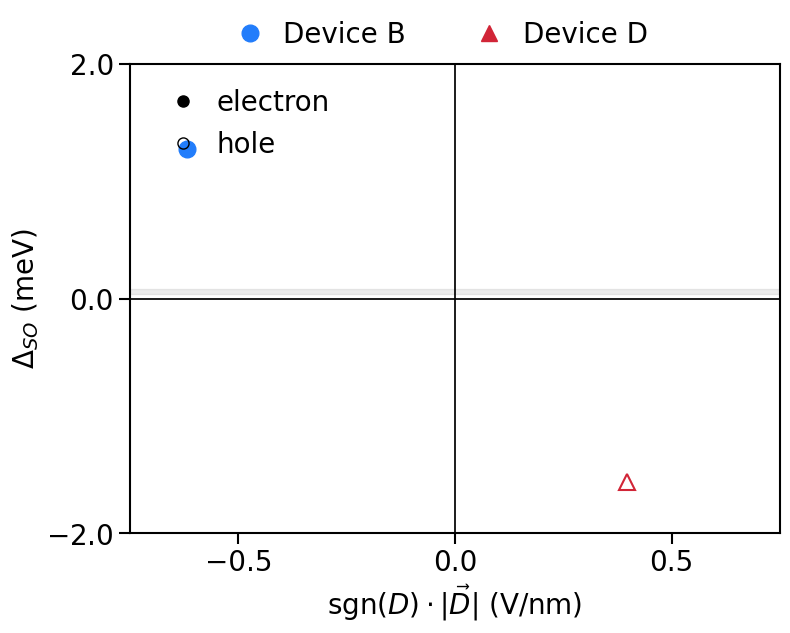

In [114]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FixedLocator

# Function to plot data with thicker edge for empty markers
def plot_data(ax, data, marker, facecolor, edgecolor, label=None):
    for point in data:
        D, delta_SO, err = point
        
        # Thicker edge for empty markers
        mew = 1.5 if facecolor == 'none' else 1.0
        
        eb = ax.errorbar(
            D, delta_SO, yerr=err if err != 0 else None, fmt=marker,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            ecolor=edgecolor,
            markersize=12,
            markeredgewidth=mew,
            label='_nolegend_'  # avoid error bar in legend
        )
        if label:
            eb[0].set_label(label)  # set label only on marker (not error bar)
            label = None

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# When calling plot_data, assign labels only to the datasets you want in legend:
# plot_data(ax, B_strong_h, 'o', facecolor='none', edgecolor=custom_blue, label=None)  # no legend for hole data
plot_data(ax, B_strong_e, 'o', facecolor=custom_blue, edgecolor=custom_blue, label='Device B')

# plot_data(ax, C_strong_h, 'o', facecolor='none', edgecolor=custom_green, label=None)  # no legend for hole data

plot_data(ax, D_strong_h, '^', facecolor='none', edgecolor=custom_red, label=None)  # no legend for hole data
plot_data(ax, [[-0.9186,-1.36,0]], '^', facecolor=custom_red, edgecolor=custom_red, label='Device D')

# Axes lines
ax.axhline(0, color='black', linewidth=1.25, linestyle='-')
ax.axvline(0, color='black', linewidth=1.25, linestyle='-')

# Gray band
ax.axhspan(0.040, 0.080, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')

# Electron and hole legend handles
electron_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markerfacecolor='black', markeredgecolor='black', markersize=8, label='electron')
hole_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black', markersize=8, label='hole')


# Labels and limits
ax.set_xlabel(r"sgn$(D)\cdot |\vec{D}|$ (V/nm)", fontsize=textsize)
ax.set_ylabel(r"$Δ_{\text{SO}}$ (meV)", fontsize=textsize)

ax.set_ylim([-2, 2])
ax.set_xlim([-0.75, 0.75])

# Tick locator (optional, adapt if needed)
ax.yaxis.set_major_locator(FixedLocator([-2, 0, 2]))
ax.set_yticklabels(['$-$2.0','0.0', '2.0'])
ax.xaxis.set_major_locator(FixedLocator([-0.5, 0, 0.5]))

# Tick label size
ax.tick_params(axis='both', which='major', labelsize=textsize)

# Extract only device handles and labels (exclude any empty or _nolegend_ labels)
handles, labels = ax.get_legend_handles_labels()
device_handles = []
device_labels = []
for h, l in zip(handles, labels):
    if l not in [None, '', '_nolegend_']:
        device_handles.append(h)
        device_labels.append(l)

# Device legend above the plot
fig.legend(device_handles, device_labels,
           ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.55, 1.07),
           fontsize=textsize,
           handletextpad=0.2,
           columnspacing=2,
           frameon=False)

# Electron/hole legend inside the plot (pass handles explicitly)
ax.legend([electron_handle, hole_handle], ['electron', 'hole'],
          loc='upper left',
          fontsize=textsize,
          handletextpad=0.2,
          columnspacing=0.8,
          frameon=False)

ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=textsize)

plt.tight_layout()

folder = "Plots"
os.makedirs(folder, exist_ok=True)

plt.savefig(os.path.join(folder, "D_fields_strong.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "D_fields_strong.pdf"), format='pdf', bbox_inches='tight')
plt.show()

## Poster 2

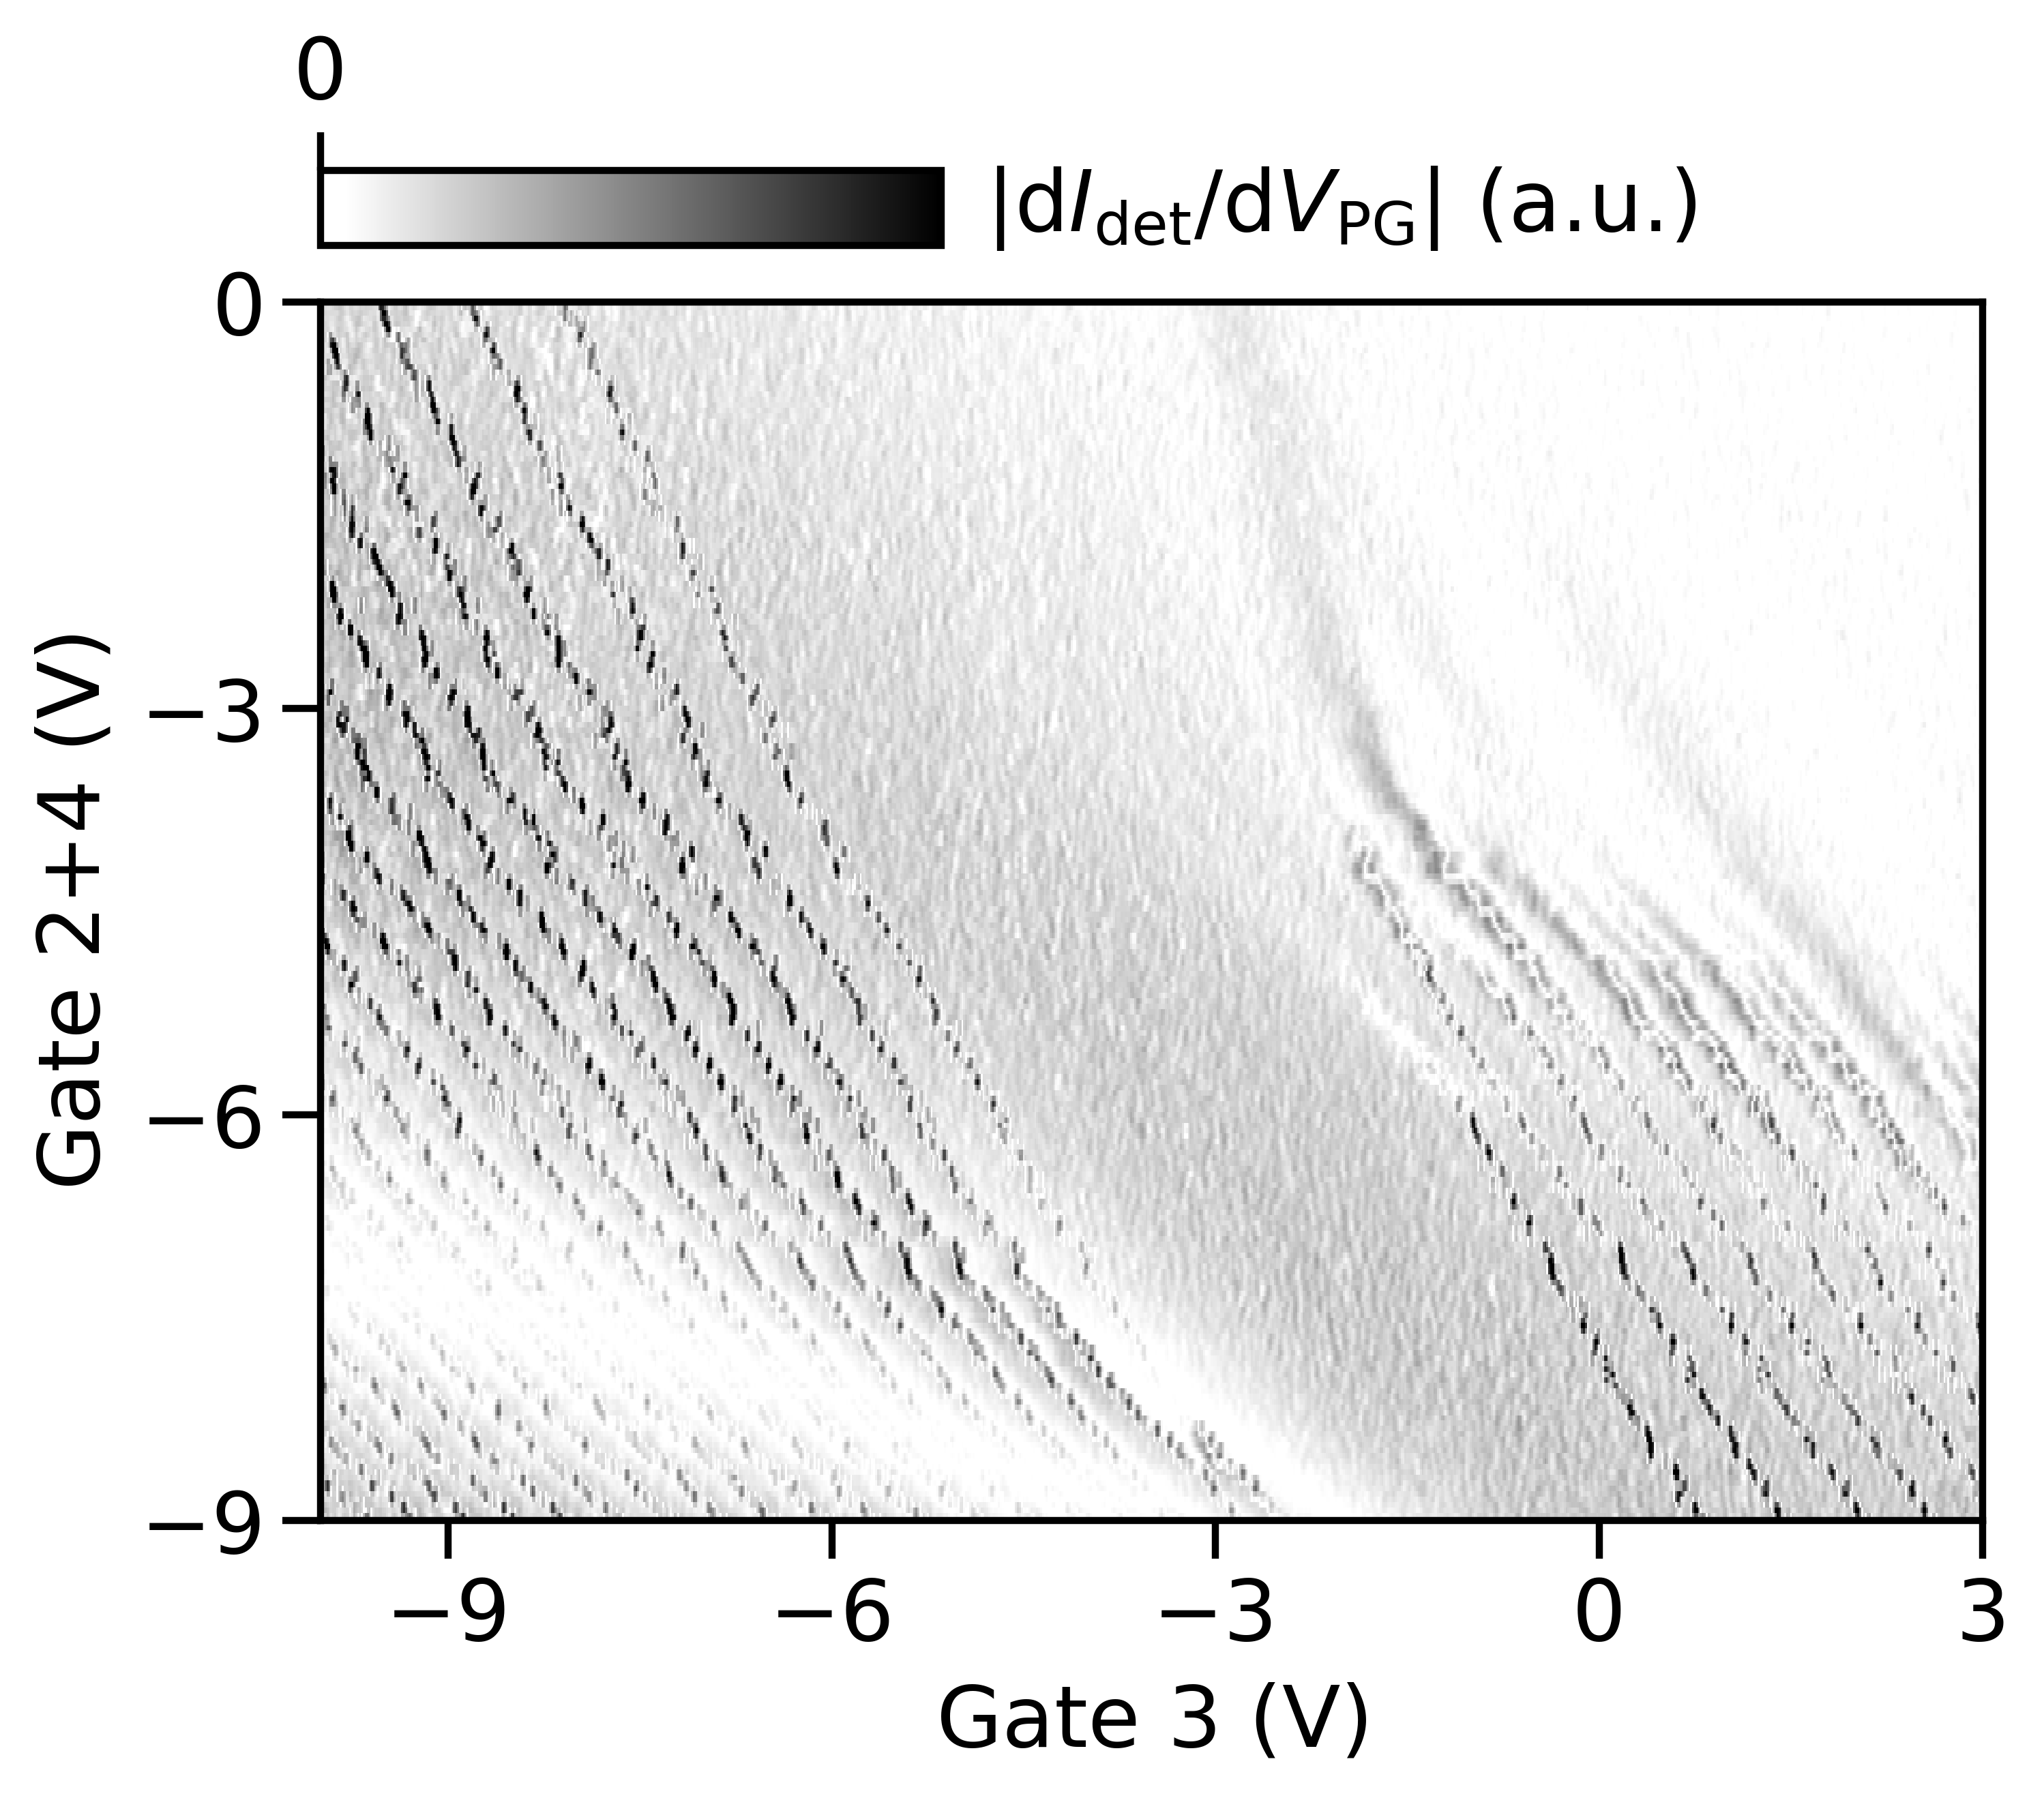

In [17]:
matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    # 'text.usetex': True
})

name='B0635 6VBG Charge det PG barier'
if MacBook == True:
    filename='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/05/Data_0520/%s.hdf5'%name
else: 
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/05/Data_0520/%s.hdf5'%name
data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

V_PG=data['Data']['Data'][:,0,:]*2
FG2=data['Data']['Data'][:,2,:]*2
FG22=data['Data']['Data'][:,1,:]*2
I_dot=data['Data']['Data'][:,3,:]*1e-8
I_det=data['Data']['Data'][:,4,:]*1e-8

# Convert raw data to physical units
x_all = V_PG 
y_all = (FG2 + FG22)/2 -0.25
z_all = I_det * 1e9 # nA

e2h = 3.8740459e-5  # e²/h in S
VSDAC = 10e-6       # Source-drain AC voltage


Igradient = np.gradient(I_det, axis=0) / VSDAC / e2h

Igradient = signal.savgol_filter(Igradient, 3, 1, deriv=0, delta=1.0, axis=0, mode='interp', cval=0.0)
Igradient = signal.savgol_filter(Igradient, 3, 1, deriv=0, delta=1.0, axis=1, mode='interp', cval=0.0)
z_all = Igradient

# Define the desired x and y range
x_range = (-10, 3)  # for Gate 3 (V)
y_range = (-9, 0)  # for B⊥ (mT)


# Compute grid centers
x_centers = x_all[:,0]  # Unique Gate 3 values (assuming constant along columns)
y_centers = y_all[0,:]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = max(abs(np.min(z_all)), np.max(z_all)) * 0.4

# Define colorbar ticks
cbar_ticks = [0]  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(6.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(z_all.T), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=10), vmin=z_min, vmax=z_max)
# ax.hlines(-0.1,np.min(x_edges)*0.99, np .max(x_edges)*1.01, colors='black', linestyles='dashed')
# Set labels and limits
ax.set_xlabel(r'$\text{Gate 3}$ (V)', labelpad=5)
ax.set_ylabel(r'$\text{Gate 2+4}$ (V)', labelpad=5)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
ax.yaxis.set_major_locator(FixedLocator([-9,-6,-3,0]))  # Explicitly set y-ticks
ax.xaxis.set_major_locator(FixedLocator([-9,-6,-3,0,3]))  # Explicitly set y-ticks


# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)

cb.ax.set_xticks([0])

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'|d$I_\text{det}/$d$V_\text{PG}|$ (a.u.)', va='center', ha='left', fontsize=18)

folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "ChargeSesning.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "ChargeSesning.pdf"), format='pdf', bbox_inches='tight')

plt.show()

matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'legend.fontsize': 24,
    # 'text.usetex': True
})


['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD Left C18 C6', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'PG Virtual', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_MG C17', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_PG Left C24', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_SD Left C18', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC x', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC theta', b''), dtype=[('name', 'O'), ('info', 'O')])]


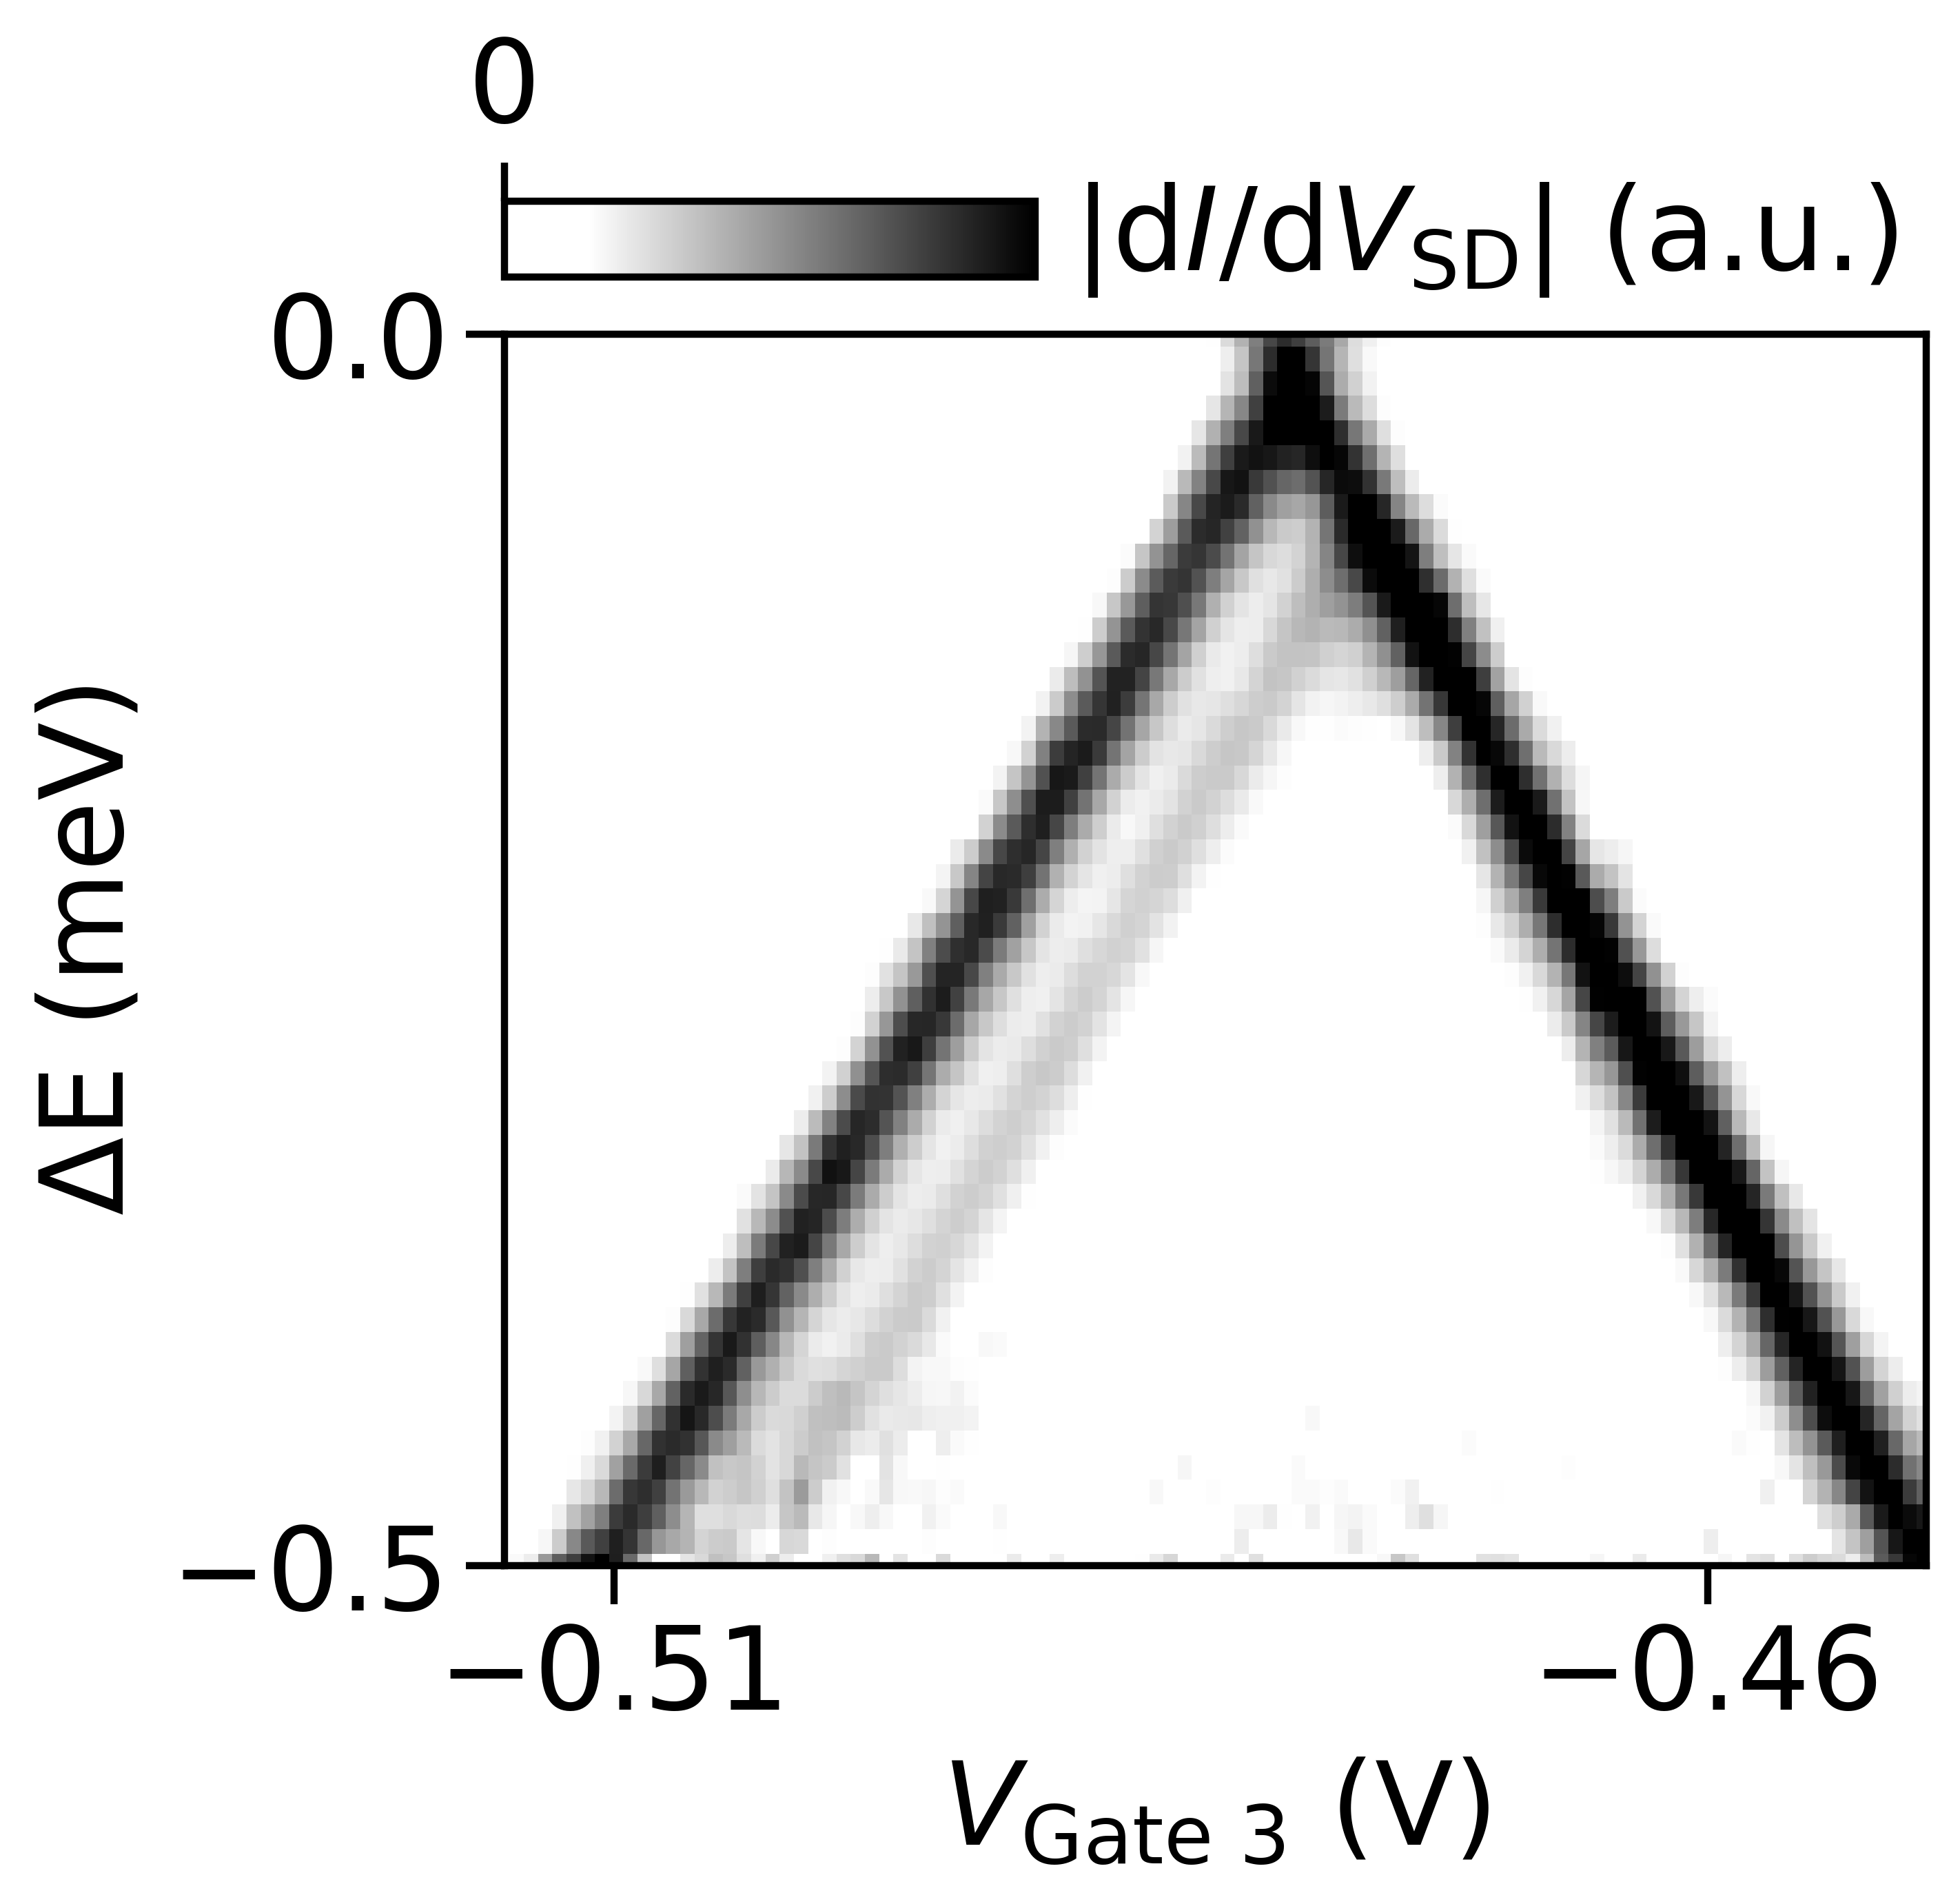

In [6]:
name='C0062 4VBGm 1e Diamond MG'
if MacBook == True:
    filemane='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,5,:]*1e-8

V_AC = 50e-6

# Convert raw data to physical units
y_all = V_PG[:, 0:101]  # Gate 3 (V)
x_all = V_SD[:, 0:101]  # B⊥ (mT)
z_all = I_ACx[:, 0:101] * 1e9 / V_AC # nA/uV

z_all = signal.savgol_filter(z_all, 2, 1, deriv=0, delta=1.0, axis=0, mode='interp', cval=0.0)
z_all = signal.savgol_filter(z_all, 2, 1, deriv=0, delta=1.0, axis=1, mode='interp', cval=0.0)


# Choose a y value above which data should be shifted
y_jump_value = 0  # V (Gate 3)
x_shift = 0  # mT shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (-0.515, -0.450)  # for Gate 3 (V)
y_range = (-0.5, 0)  # for B⊥ (mT)

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 0
z_max = 600

# Define colorbar ticks
cbar_ticks = [0]  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)

# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(z_all), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=40), vmin=z_min, vmax=z_max)
# ax.hlines(-0.1,np.min(x_edges)*0.99, np .max(x_edges)*1.01, colors='black', linestyles='dashed')
# Set labels and limits
ax.set_xlabel(r'$V_{\text{Gate 3}}$ (V)', labelpad=5)
ax.set_ylabel(r'$\Delta$E (meV)', labelpad=5)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
ax.yaxis.set_major_locator(FixedLocator([-0.5, 0]))  # Explicitly set y-ticks
ax.xaxis.set_major_locator(FixedLocator([-0.51,-0.46]))  # Explicitly set y-ticks


# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)
cb.set_ticks(cbar_ticks)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{SD}|$ (a.u.)', va='center', ha='left',fontsize=24)

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "Electron_Negative_Diamond.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "Electron_Negative_Diamond.pdf"), format='pdf', bbox_inches='tight')
plt.show()

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD Left C18 C6', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'PG-virtual', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_PG Left C24', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_SD Left C18', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC x', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC theta', b''), dtype=[('name', 'O'), ('info', 'O')])]


C:\Users\User\AppData\Local\Temp\ipykernel_16512\3402377196.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


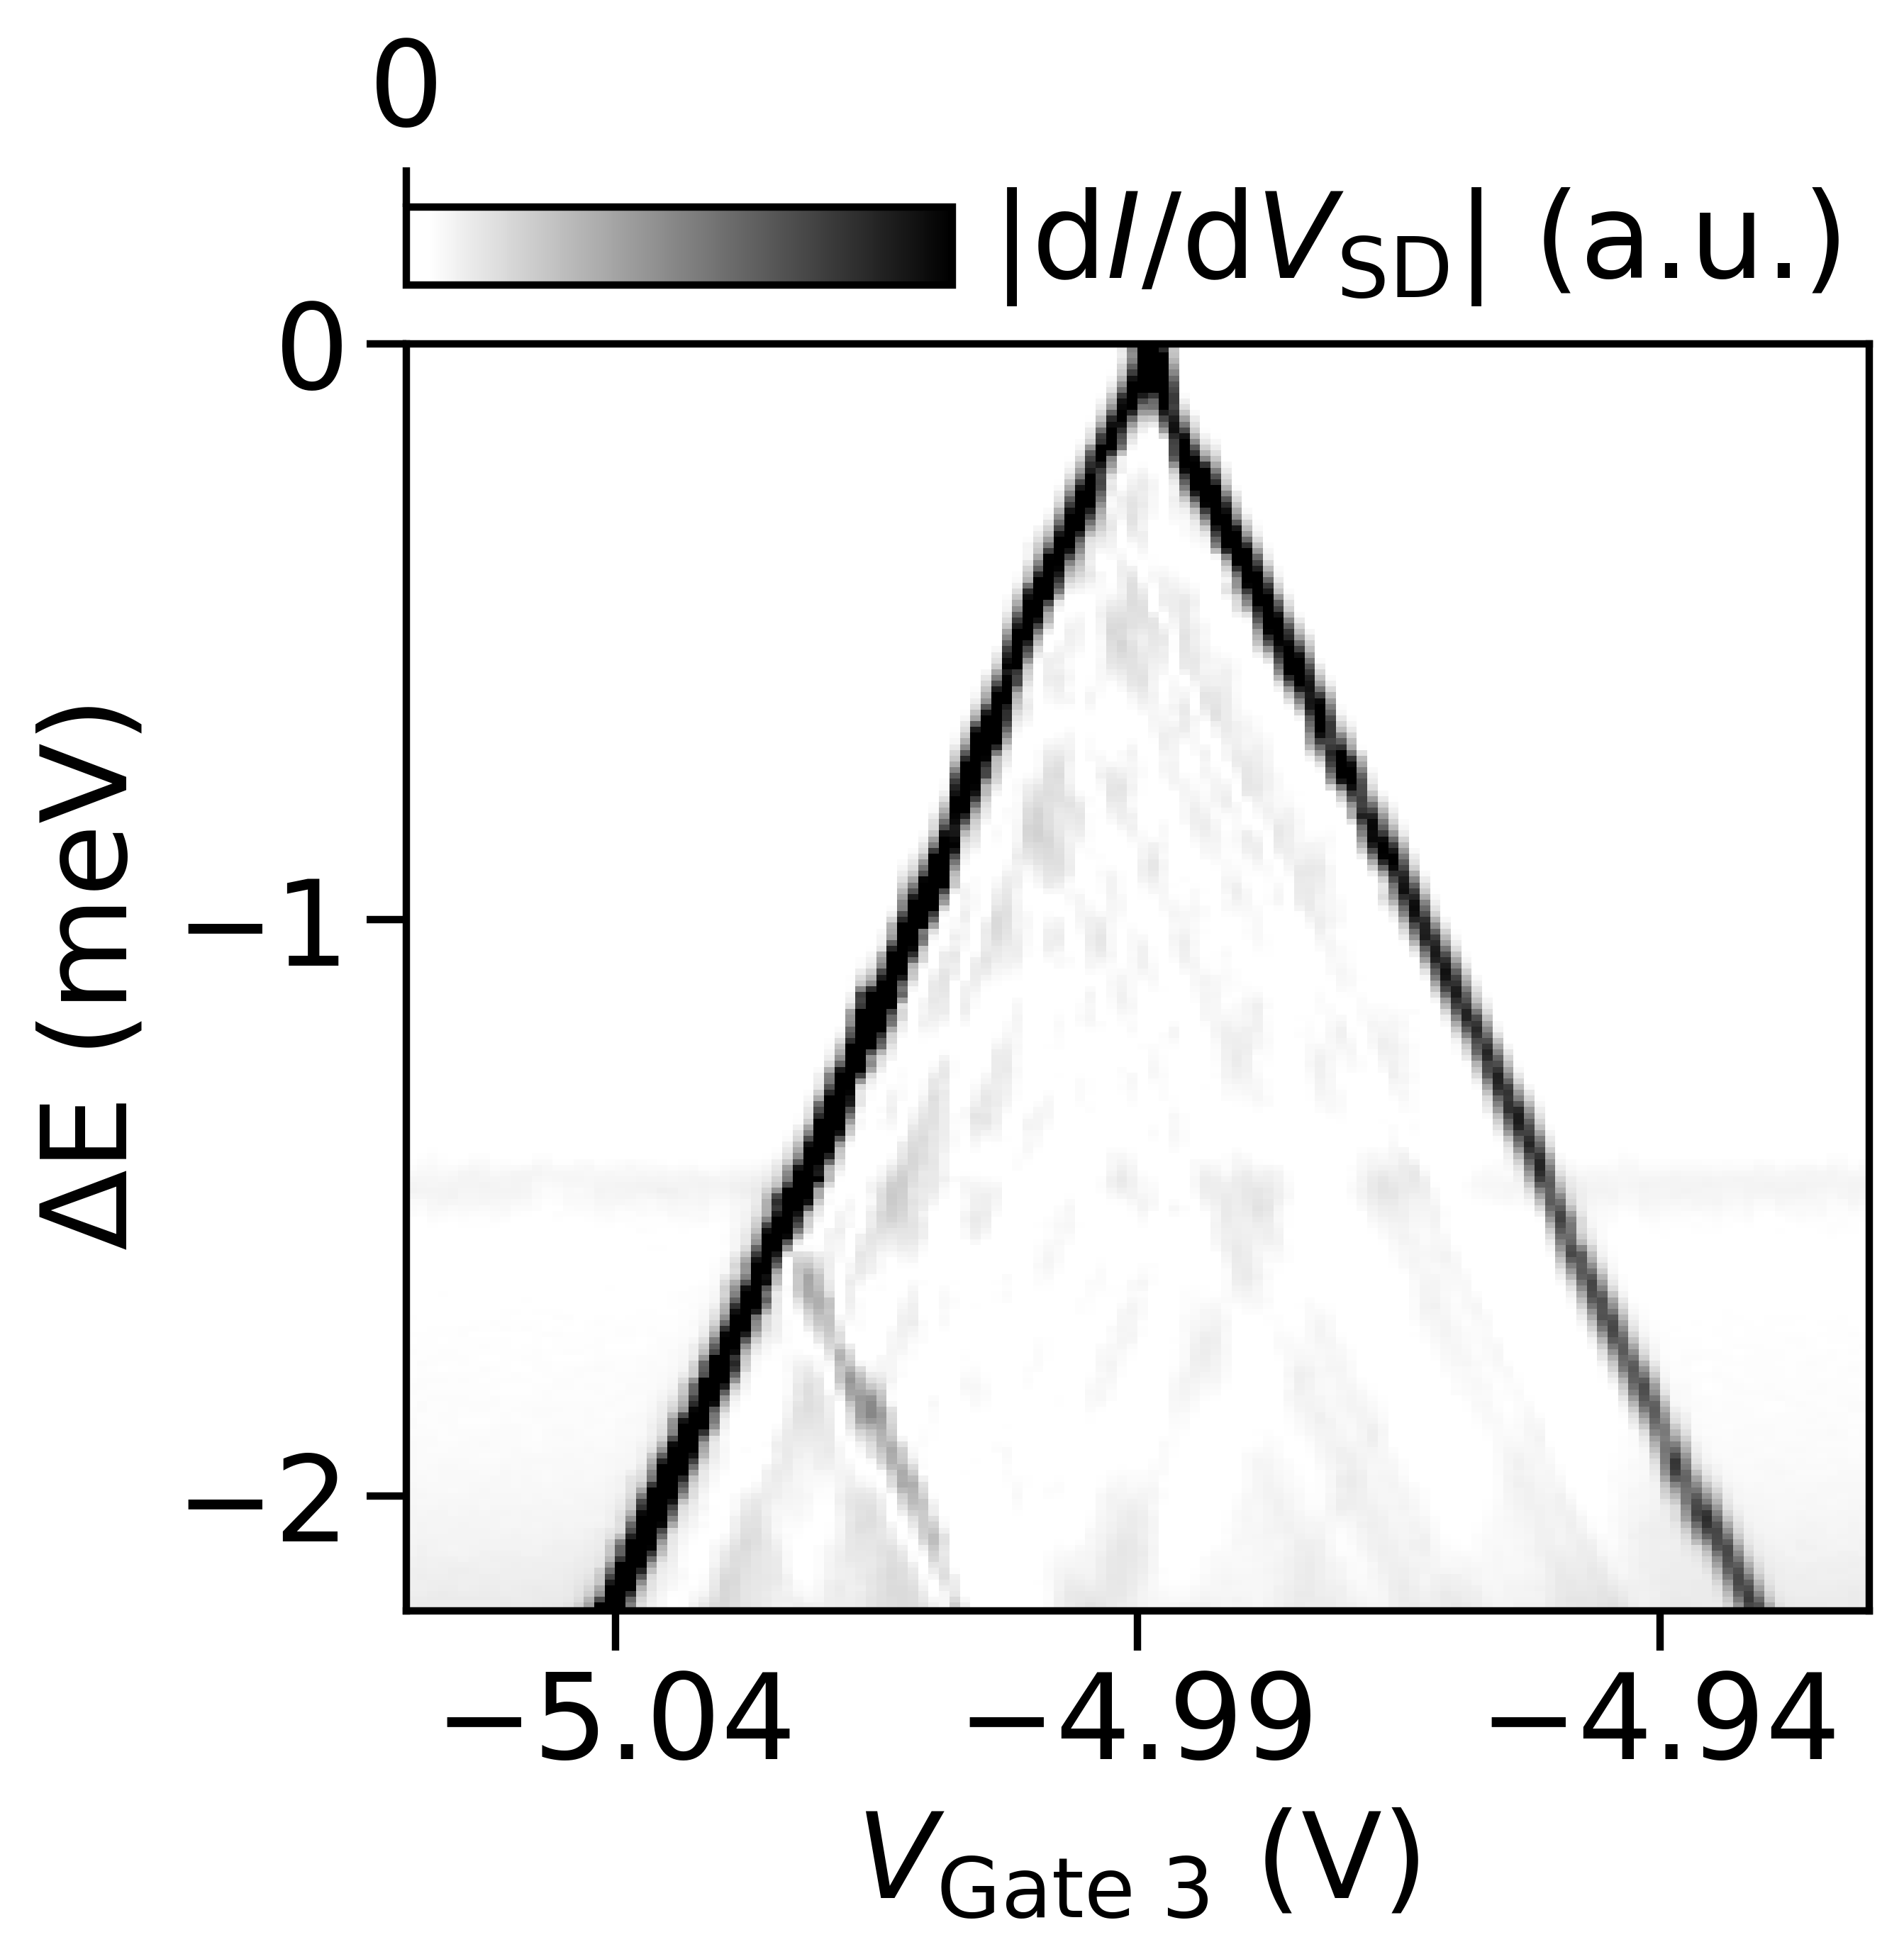

In [7]:
name='B0451  6VBG 1h diamond lever arm'
if MacBook == True:
    filename='/Volumes/groupdata/nano/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/04/Data_0427/%s.hdf5'%name
else:
    filename='N:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025/2025/04/Data_0427/%s.hdf5'%name
data = h5py.File(filename, 'r')

print([i for i in data])#Open just for reading "r"
print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,2,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,4,:]*1e-8
# print(I_ACx)
# VSDAC=20e-6
# ---

# Convert raw data to physical units
y_all = V_PG          # Gate 3 (V)
x_all = V_SD          # ΔE (mV)
z_all = I_ACx * 1e12  # pA


z_all = signal.savgol_filter(z_all, 2, 1, deriv=0, delta=1.0, axis=0, mode='interp', cval=0.0)
z_all = signal.savgol_filter(z_all, 2, 1, deriv=0, delta=1.0, axis=1, mode='interp', cval=0.0)

# Choose a y value above which data should be shifted
y_jump_value = 0
x_shift = 0

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (-2.2, 0)       # ΔE (mV)
y_range = (-5.06, -4.92) # Gate 3 (V)

# Mask data within range
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))


z_min = 0
z_max = 17

cbar_ticks = [0]  # e.g., [40, 20, 0]


# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=500)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])

# pcolormesh (note: x=Gate 3 (vertical in data), y=ΔE (horizontal))
pcm = ax.pcolormesh(x_edges, y_edges, np.abs(z_all-1.2), cmap=create_white_to_color_cmap(color=(0, 0, 0, 1), white_width=10),
                    vmin=z_min, vmax=z_max)

# Labels and limits
ax.set_xlabel(r'$V_{\text{Gate 3}}$ (V)', labelpad=5, fontsize=24)
ax.set_ylabel(r'$\Delta$E (meV)', labelpad=5, fontsize=24)
ax.set_xlim(y_range)
ax.set_ylim(x_range)
ax.xaxis.set_major_locator(FixedLocator([-5.04, -4.99, -4.94]))
ax.yaxis.set_major_locator(FixedLocator([-2, -1, 0]))
ax.tick_params(labelsize=24)

# Colourbar above plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.28, 0.04])
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(labelsize=24, direction='out', which='major',
                  top=True, bottom=False, labeltop=True, labelbottom=False)
cbar_ticks = [0]  # e.g., [40, 20, 0]
cb.set_ticks(cbar_ticks)
cb.update_ticks()

# Colourbar label
label_ax = fig.add_axes([0.45, 0.825, 0.35, 0.05])
label_ax.axis('off')
label_ax.text(0, 0.5, r'$|\text{d}I/\text{d}V_\text{SD}|$ (a.u.)', va='center', ha='left',fontsize=24)

# Save and show
folder = "Plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "plot.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "plot.pdf"), format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17880\2205984583.py:62: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry


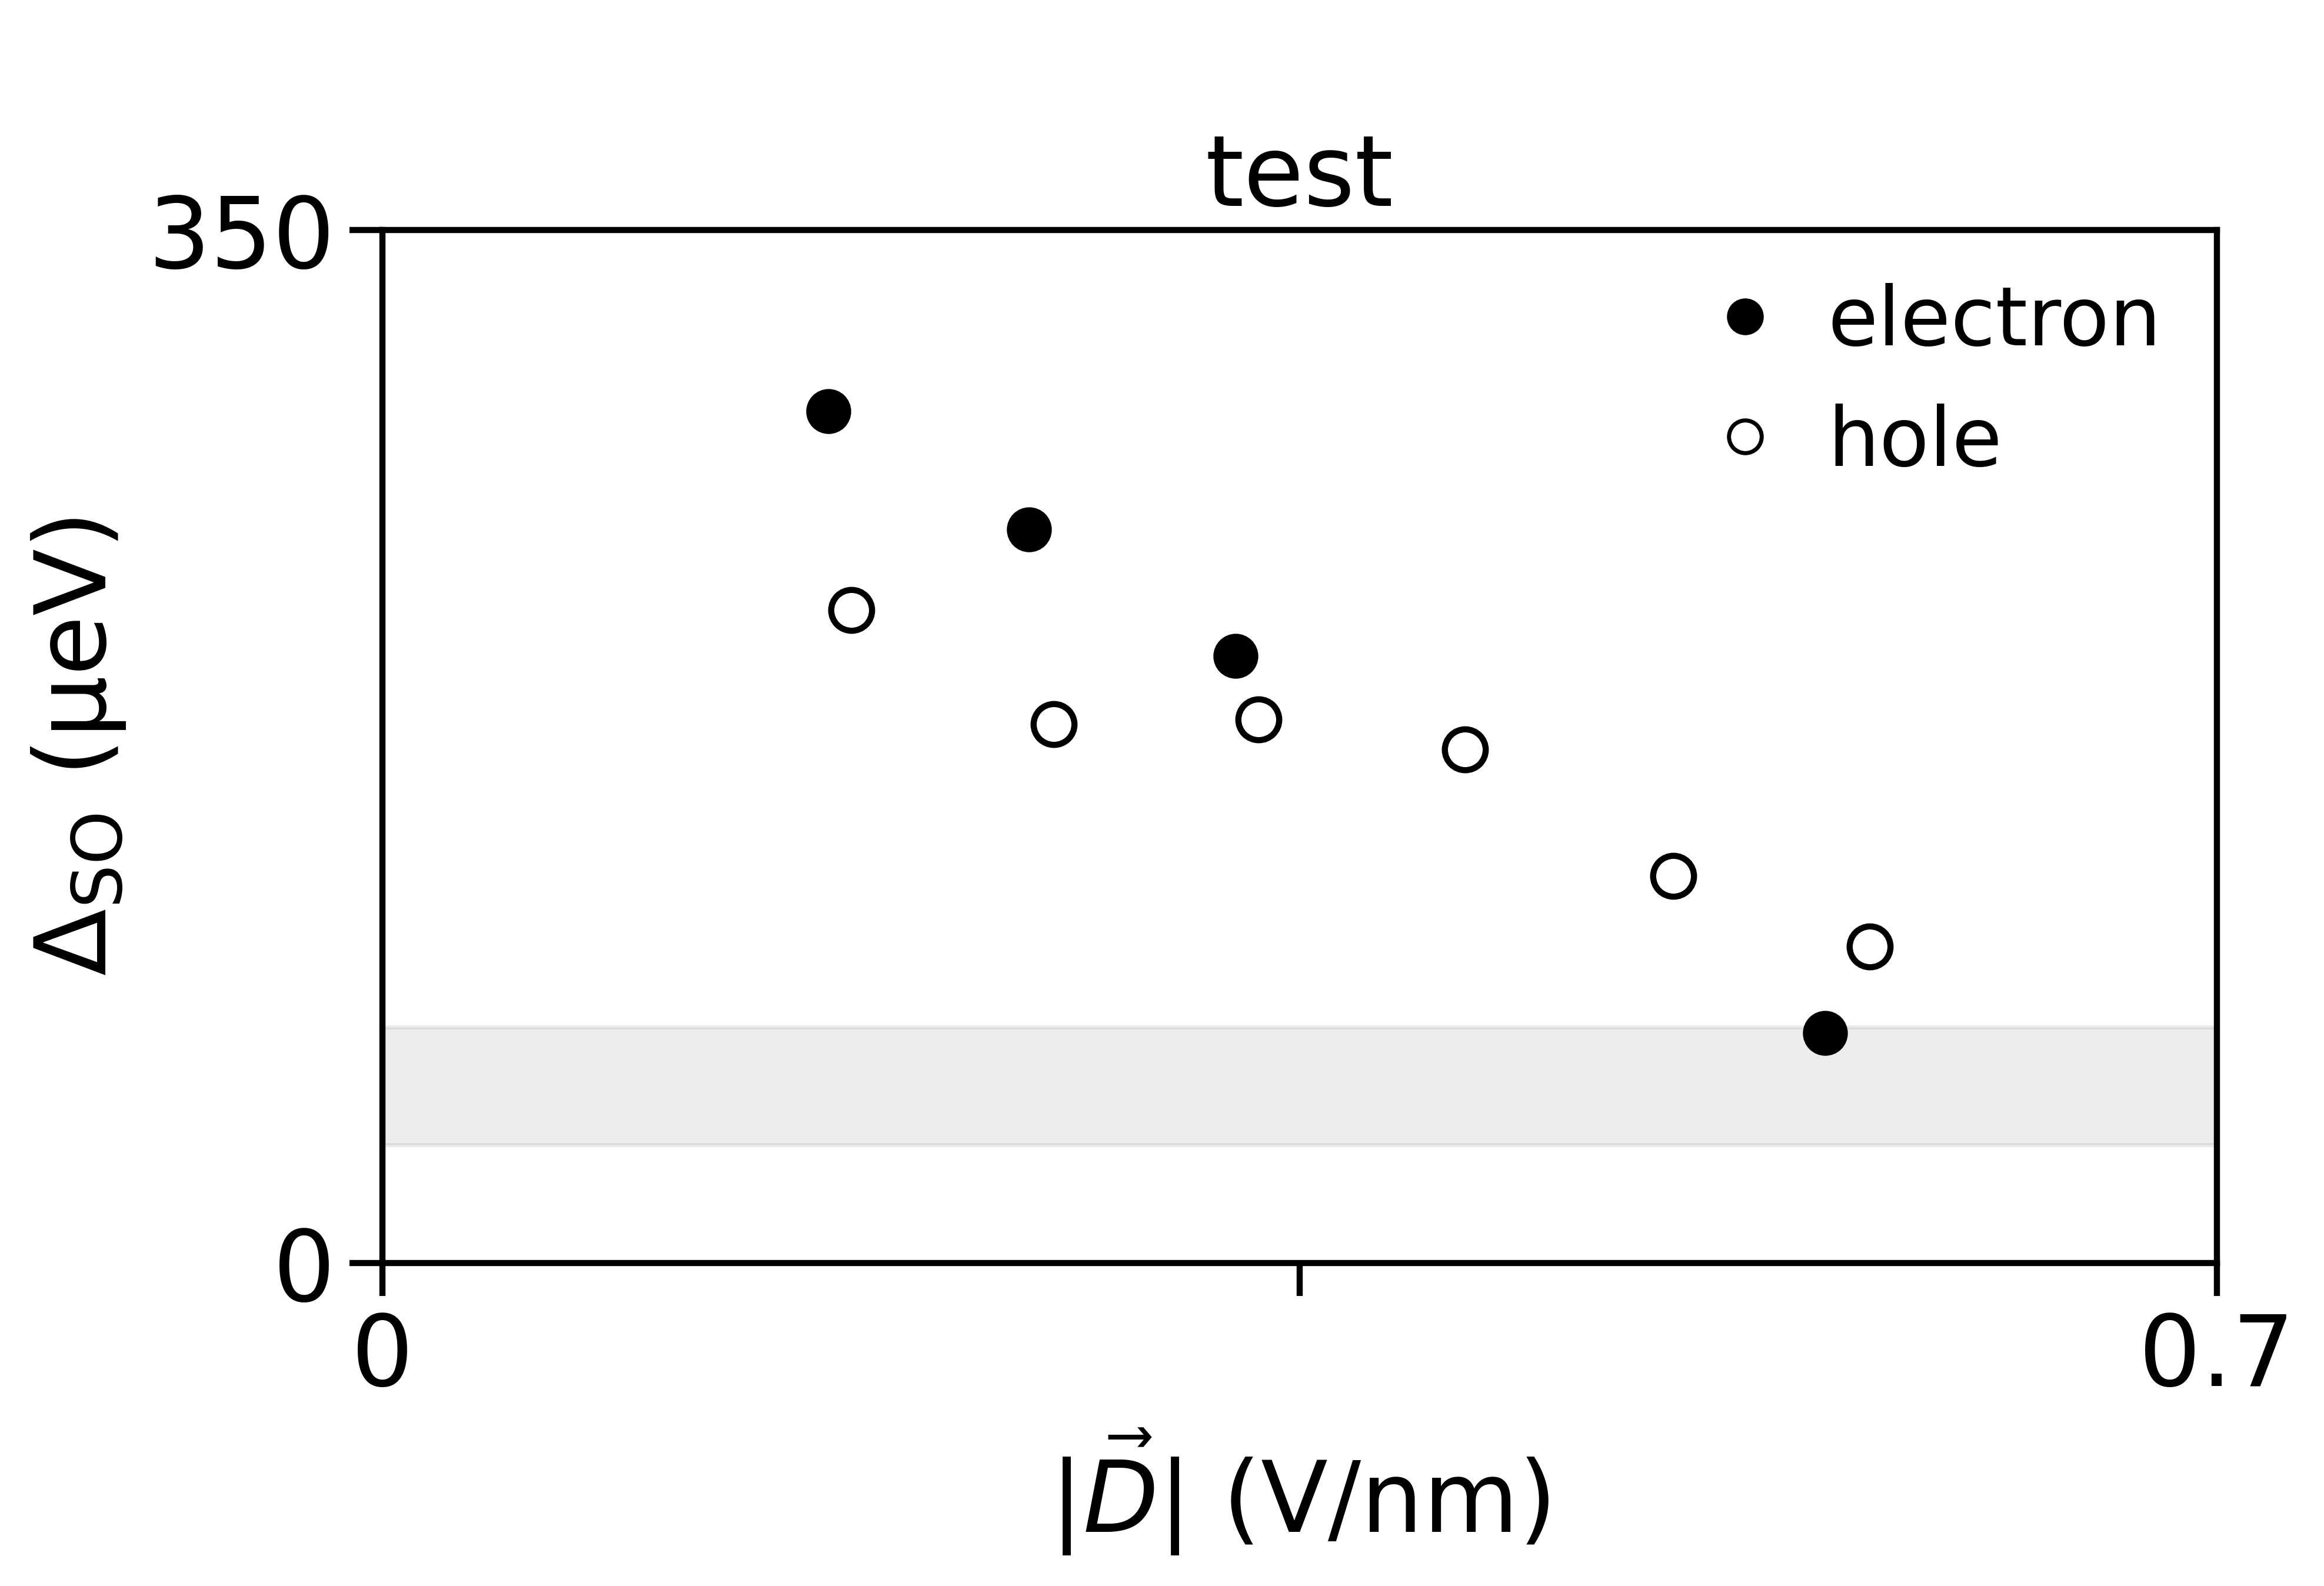

In [8]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

textsize = 24

A_weak_h = [[0.5676,107.28,55/2], [0.4927,+131.10,88/2], [0.4132,+173.99,80/2], [0.3344,184.21,89/2], [0.2562,182.62,41/2], [0.1789,+221.22,42/2]]
A_weak_e = [[0.3256,205.75,0],[0.2467,248.42,0],[0.1702,288.63,0]]

# B_strong_h = [[0.7033,1.41749,0.02], [0.5474,1.41946,0.02], [0.3928,1.45471,0.02], [0.264,1.48055,0.02]] 
# B_strong_e = [[-0.6182,1.27319,0.017171]]

C_weak_e = [[0.16,86,10]]
# C_strong_h = [[-0.16, -1.650,0]] #errors to do!

# D_weak_h = [[0.3186,150,0]] #errors to do!
D_weak_e = [[0.5506,78,0], 
            # [0.4172,76,0], [0.2848,73,0]
           ] #errors to do!
# D_strong_h = [[0.3977,-1.56,0]] #errors to do!
# D_strong_e = [[-0.3186,-1.36,0]] #errors to do!

# Function to plot data
def plot_data(ax, data, marker, facecolor, edgecolor, label=None):
    for point in data:
        D, delta_SO, err = point
        
        # If the marker is empty, set thicker edge
        mew = 1.5 if facecolor == 'none' else 1.0  # adjust thickness as you like
        
        eb = ax.errorbar(
            D, delta_SO, yerr= None, fmt=marker,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            ecolor=edgecolor,
            markersize=10,
            markeredgewidth=mew,  # <-- set edge width here
            label='_nolegend_'  # Prevent error bars in legend
        )
        if label:
            eb[0].set_label(label)
            label = None

# Set up plot
fig, ax = plt.subplots(figsize=(8, 5.15), dpi=500)

# Plot A
plot_data(ax, A_weak_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, A_weak_e, 'o', facecolor='black', edgecolor='black', label='')

# Plot C
# plot_data(ax, C_weak_e, 'D', facecolor='black', edgecolor='black', label='')

# Plot D
# plot_data(ax, D_weak_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, D_weak_e, 'o', facecolor='black', edgecolor='black', label='')

ax.axhline(0, color='black', linewidth=1.25, linestyle='-')  # horizontal line at Δ_SO = 0
ax.axvline(0, color='black', linewidth=1.25, linestyle='-')  # vertical line at D = 0


# Add gray band between 40 and 80 μeV
ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry

# Custom legend handles for electron and hole markers
electron_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markerfacecolor='black', markeredgecolor='black', markersize=8, label='electron')
hole_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black', markersize=8, label='hole')

# Get existing legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Add electron and hole marker to legend
handles.extend([electron_handle, hole_handle])
labels.extend(['electron', 'hole'])

# Finalize plot
ax.set_xlabel(r"$|\vec{D}|$ (V/nm)",labelpad=5,fontsize=textsize)
ax.set_ylabel(r"$Δ_{\text{SO}}$ (µeV)", labelpad=5,fontsize=textsize)
# ax.set_title(r"Spin-Orbit Gap vs Displacement Field")
ax.set_ylim([0,350])
ax.set_xlim([0,0.7])
ax.yaxis.set_major_locator(FixedLocator([0,350]))  # Explicitly set y-ticks
ax.set_yticklabels(['0', '350'])
ax.xaxis.set_major_locator(FixedLocator([0,0.35,0.7]))  # Explicitly set y-ticks
ax.set_xticklabels(['0', '','0.7'])

device_handles = handles[:-2]  # All except last two (electron, hole)
device_labels = labels[:-2]

electron_hole_handles = handles[-2:]
electron_hole_labels = labels[-2:]

# --- 2. Add the device legend above the plot ---
# Place the device legend manually using `fig.legend` instead of `ax.legend`
fig.legend(device_handles, device_labels,
           ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.55, 1.07),  # Slightly above the top of the plot
           fontsize=textsize,
           handletextpad=0.2,
           columnspacing=2,
           frameon=False)  # Optional: no box

# --- 3. Add the electron/hole legend in plot (bottom right) ---
# ax.legend(electron_hole_handles, electron_hole_labels,
#            ncol=1,
#            loc='upper right',
#            bbox_to_anchor=(1.1, 1.1),
#           handletextpad=0.01,
#           frameon=False)  # ← no edge
# ax.grid(False)

ax.legend([electron_handle, hole_handle], ['electron', 'hole'],
          loc='upper right',
          fontsize=20,
          bbox_to_anchor=(1.01, 1.02),
          handletextpad=0.01,
          columnspacing=0.5,
          frameon=False)

ax.tick_params(axis='both', which='major', labelsize=textsize)

plt.title('test')
plt.tight_layout()

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "D_fields_weak.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "D_fields_weak.pdf"), format='pdf', bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17880\190221932.py:62: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry


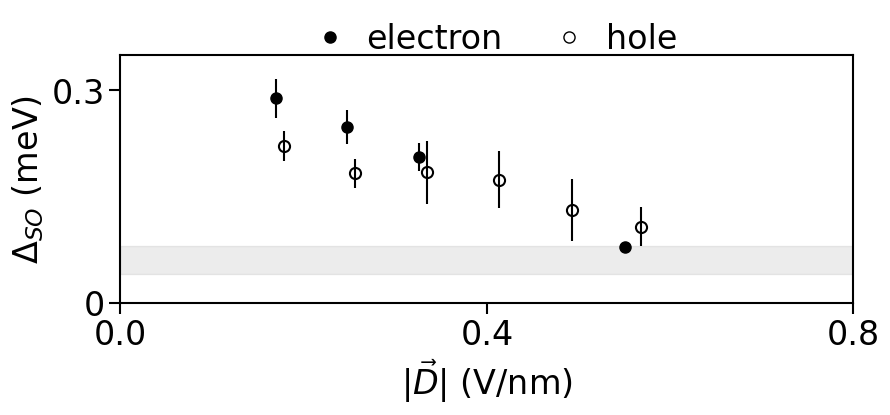

In [6]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

textsize = 24

A_weak_h = [[0.5676,107.28,55/2], [0.4927,+131.10,88/2], [0.4132,+173.99,80/2], [0.3344,184.21,89/2], [0.2562,182.62,41/2], [0.1789,+221.22,42/2]]
A_weak_e = [[0.3256,205.75,20],[0.2467,248.42,24],[0.1702,288.63,28]]

# B_strong_h = [[0.7033,1.41749,0.02], [0.5474,1.41946,0.02], [0.3928,1.45471,0.02], [0.264,1.48055,0.02]] 
# B_strong_e = [[-0.6182,1.27319,0.017171]]

C_weak_e = [[0.16,86,10]]
# C_strong_h = [[-0.16, -1.650,0]] #errors to do!

# D_weak_h = [[0.3186,150,0]] #errors to do!
D_weak_e = [[0.5506,78,0], 
            # [0.4172,76,0], [0.2848,73,0]
           ] #errors to do!
# D_strong_h = [[0.3977,-1.56,0]] #errors to do!
# D_strong_e = [[-0.3186,-1.36,0]] #errors to do!

# Function to plot data
def plot_data(ax, data, marker, facecolor, edgecolor, label=None):
    for point in data:
        D, delta_SO, err = point
        
        # If the marker is empty, set thicker edge
        mew = 1.5 if facecolor == 'none' else 1.0  # adjust thickness as you like
        
        eb = ax.errorbar(
            D, delta_SO, yerr=err if err != 0 else None, fmt=marker,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            ecolor=edgecolor,
            markersize=8,
            markeredgewidth=mew,  # <-- set edge width here
            label='_nolegend_'  # Prevent error bars in legend
        )
        if label:
            eb[0].set_label(label)
            label = None

# Set up plot
fig, ax = plt.subplots(figsize=(9,4.5))

# Plot A
plot_data(ax, A_weak_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, A_weak_e, 'o', facecolor='black', edgecolor='black', label='')

# Plot C
# plot_data(ax, C_weak_e, 'D', facecolor='black', edgecolor='black', label='')

# Plot D
# plot_data(ax, D_weak_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, D_weak_e, 'o', facecolor='black', edgecolor='black', label='')

ax.axhline(0, color='black', linewidth=1.25, linestyle='-')  # horizontal line at Δ_SO = 0
ax.axvline(0, color='black', linewidth=1.25, linestyle='-')  # vertical line at D = 0


# Add gray band between 40 and 80 μeV
ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry

# Custom legend handles for electron and hole markers
electron_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markerfacecolor='black', markeredgecolor='black', markersize=8, label='electron')
hole_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black', markersize=8, label='hole')

# Get existing legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Add electron and hole marker to legend
handles.extend([electron_handle, hole_handle])
labels.extend(['electron', 'hole'])

# Finalize plot
ax.set_xlabel(r"$|\vec{D}|$ (V/nm)",fontsize=textsize)
ax.set_ylabel(r"$Δ_{SO}$ (meV)",fontsize=textsize)
# ax.set_title(r"Spin-Orbit Gap vs Displacement Field")
ax.set_ylim([0,350])
ax.set_xlim([0,0.8])
ax.yaxis.set_major_locator(FixedLocator([0,300]))  # Explicitly set y-ticks
ax.set_yticklabels(['0', '0.3'])
ax.xaxis.set_major_locator(FixedLocator([0,0.4,0.8]))  # Explicitly set y-ticks

device_handles = handles[:-2]  # All except last two (electron, hole)
device_labels = labels[:-2]

electron_hole_handles = handles[-2:]
electron_hole_labels = labels[-2:]

# --- 2. Add the device legend above the plot ---
# Place the device legend manually using `fig.legend` instead of `ax.legend`
# fig.legend(device_handles, device_labels,
#            ncol=3,
#            loc='upper center',
#            bbox_to_anchor=(0.55, 1.07),  # Slightly above the top of the plot
#            fontsize=textsize,
#            handletextpad=0.2,
#            columnspacing=2,
#            frameon=False)  # Optional: no box

# --- 3. Add the electron/hole legend in plot (bottom right) ---
ax.legend(electron_hole_handles, electron_hole_labels,
           ncol=2,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.25),
          handletextpad=0.1,
          columnspacing=1,
          frameon=False)  # ← no edge
ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=textsize)

plt.tight_layout()

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "D_fields_weak.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "D_fields_weak.pdf"), format='pdf', bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17880\192529422.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry


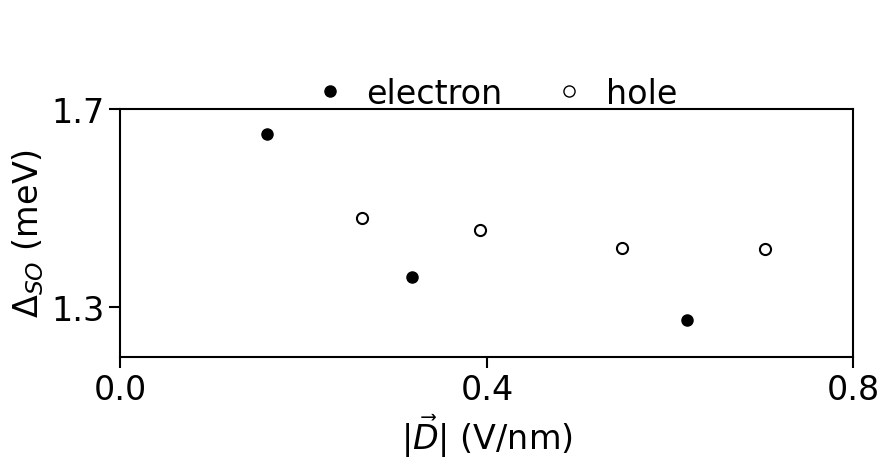

In [7]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

textsize = 24

# A_weak_h = [[0.5676,107.28,55/2], [0.4927,+131.10,88/2], [0.4132,+173.99,80/2], [0.3344,184.21,89/2], [0.2562,182.62,41/2], [0.1789,+221.22,42/2]]
# A_weak_e = [[0.3256,205.75,0],[0.2467,248.42,0],[0.1702,288.63,0]]

B_strong_h = [[0.7033,1.41749,0], [0.5474,1.41946,0], [0.3928,1.45471,0], [0.264,1.48055,0]] 
B_strong_e = [[0.6182,1.27319,0]]

# C_weak_e = [[0.16,86,10]]
C_strong_h = [[0.16, 1.650,0]] #errors to do!

# D_weak_h = [[0.3186,150,0]] #errors to do!
# D_weak_e = [[0.5506,78,0], 
            # [0.4172,76,0], [0.2848,73,0]] #errors to do!
D_strong_h = [[0.3977,1.56,0]] #errors to do!
D_strong_e = [[0.3186,1.36,0]] #errors to do!

# Function to plot data
def plot_data(ax, data, marker, facecolor, edgecolor, label=None):
    for point in data:
        D, delta_SO, err = point
        
        # If the marker is empty, set thicker edge
        mew = 1.5 if facecolor == 'none' else 1.0  # adjust thickness as you like
        
        eb = ax.errorbar(
            D, delta_SO, yerr=err if err != 0 else None, fmt=marker,
            markerfacecolor=facecolor,
            markeredgecolor=edgecolor,
            ecolor=edgecolor,
            markersize=8,
            markeredgewidth=mew,  # <-- set edge width here
            label='_nolegend_'  # Prevent error bars in legend
        )
        if label:
            eb[0].set_label(label)
            label = None

# Set up plot
fig, ax = plt.subplots(figsize=(9, 4.5))

# Plot A
plot_data(ax, B_strong_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, B_strong_e, 'o', facecolor='black', edgecolor='black', label='')

# Plot C
plot_data(ax, C_strong_h, 'o', facecolor='black', edgecolor='black', label='')

# Plot D
# plot_data(ax, D_strong_h, 'o', facecolor='none', edgecolor='black', label='')
plot_data(ax, D_strong_e, 'o', facecolor='black', edgecolor='black', label='')

ax.axhline(0, color='black', linewidth=1.25, linestyle='-')  # horizontal line at Δ_SO = 0
ax.axvline(0, color='black', linewidth=1.25, linestyle='-')  # vertical line at D = 0


# Add gray band between 40 and 80 μeV
ax.axhspan(40, 80, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry

# Custom legend handles for electron and hole markers
electron_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markerfacecolor='black', markeredgecolor='black', markersize=8, label='electron')
hole_handle = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                            markerfacecolor='none', markeredgecolor='black', markersize=8, label='hole')

# Get existing legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Add electron and hole marker to legend
handles.extend([electron_handle, hole_handle])
labels.extend(['electron', 'hole'])

# Finalize plot
ax.set_xlabel(r"$|\vec{D}|$ (V/nm)",fontsize=textsize)
ax.set_ylabel(r"$Δ_{SO}$ (meV)",fontsize=textsize)
# ax.set_title(r"Spin-Orbit Gap vs Displacement Field")
ax.set_ylim([1.2,1.7])
ax.set_xlim([0,0.8])
ax.yaxis.set_major_locator(FixedLocator([1.3,1.7]))  # Explicitly set y-ticks
ax.set_yticklabels(['1.3', '1.7'])
ax.xaxis.set_major_locator(FixedLocator([0,0.4,0.8]))  # Explicitly set y-ticks

device_handles = handles[:-2]  # All except last two (electron, hole)
device_labels = labels[:-2]

electron_hole_handles = handles[-2:]
electron_hole_labels = labels[-2:]

# --- 2. Add the device legend above the plot ---
# Place the device legend manually using `fig.legend` instead of `ax.legend`
fig.legend(device_handles, device_labels,
           ncol=3,
           loc='upper center',
           bbox_to_anchor=(0.55, 1.07),  # Slightly above the top of the plot
           fontsize=textsize,
           handletextpad=0.2,
           columnspacing=2,
           frameon=False)  # Optional: no box

# --- 3. Add the electron/hole legend in plot (bottom right) ---
ax.legend(electron_hole_handles, electron_hole_labels,
           ncol=2,
           loc='upper center',
           bbox_to_anchor=(0.5, 1.25),
          handletextpad=0.1,
          columnspacing=1,
          frameon=False)  # ← no edge
ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=textsize)

plt.tight_layout()

folder = "Plots"  # Relative or absolute path

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save the figure
plt.savefig(os.path.join(folder, "D_fields_weak.png"), format='png', dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(folder, "D_fields_weak.pdf"), format='pdf', bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7884\428875230.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axhspan(0.040, 0.080, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry


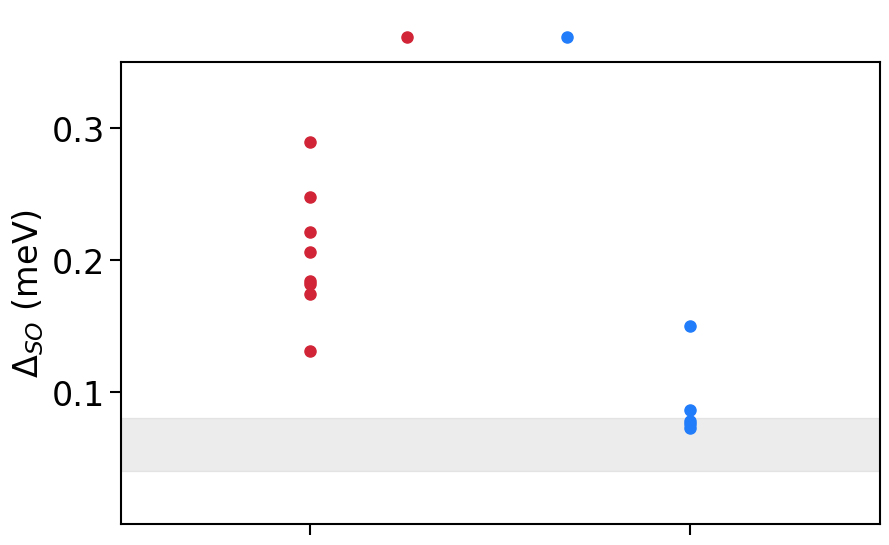

In [14]:
textsize = 24
import matplotlib.lines as mlines
# -----------------------------
# Data (in micro-eV → meV)
# -----------------------------
device_A = [131, 174, 182, 184, 206, 221, 248, 289]
device_CD = [73, 76, 78, 86, 150]

device_A = [v / 1000 for v in device_A]
device_CD = [v / 1000 for v in device_CD]
# X positions for categories
x_A = 0
x_CD = 1

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot Device A (red)
ax.plot(
    [x_A] * len(device_A),
    device_A,
    'o',
    color=custom_red,
    markersize=8,
    label='Device A'
)

# Plot Device C/D (blue)
ax.plot(
    [x_CD] * len(device_CD),
    device_CD,
    'o',
    color=custom_blue,
    markersize=8,
    label='Device C/D'
)

# -----------------------------
# Axis styling (same as before)
# -----------------------------
ax.set_ylabel(r"$Δ_{SO}$ (meV)", fontsize=textsize)

ax.set_ylim([0, 0.350])
ax.yaxis.set_major_locator(FixedLocator([0.100, 0.200, 0.300]))
ax.tick_params(axis='y', labelsize=textsize)

# Categorical x-axis
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([x_A, x_CD])
ax.set_xticklabels(['', ''], fontsize=textsize)

# Optional horizontal reference line
ax.axhline(0, color='black', linewidth=1.25)
ax.axhspan(0.040, 0.080, color='gray', alpha=0.15, edgecolor='none', label='_nolegend_')  # _nolegend_ skips legend entry
# -----------------------------
# Legend
# -----------------------------
legend_handles = [
    mlines.Line2D([], [], color=custom_red, marker='o', linestyle='None',
                  markersize=8, label=''),
    mlines.Line2D([], [], color=custom_blue, marker='o', linestyle='None',
                  markersize=8, label='')
]

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=textsize,
    frameon=False
)

ax.grid(False)
plt.tight_layout()
plt.show()